In [195]:
# import core packages
import pandas as pd
import numpy as np
import os
import snowflake.connector as snow
import pyreadstat
import xlsxwriter
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import NamedStyle

# see all columns
pd.set_option('display.max_columns', None)

# define enviro variables
user = os.environ['USER']
username = os.environ["SNOWFLAKE_USER"]
sf_pass = os.environ["SNOWFLAKE_PASSWORD"]

# set working directory
os.chdir(f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/Shared drives/Insights")
# see all columns
pd.set_option('display.max_columns', None)

# establish snowflake connection
conn = snow.connect(
    user=username,
    password=sf_pass,
    account='avb99459.us-east-1',
    warehouse='OPPORTUNITYATWORK_WH',
    role='PUBLIC'
)

cur = conn.cursor()

In [196]:
import pandas as pd
import os

base = f"/Users/{os.environ['USER']}/Documents/USF/ECON696"

# ── Load Anthropic Economic Index (observed_exposure) from HuggingFace ──
url = "https://huggingface.co/datasets/Anthropic/EconomicIndex/resolve/main/labor_market_impacts/job_exposure.csv"
anthropic_raw = pd.read_csv(url)
anthropic_raw['occ_code_7'] = anthropic_raw['occ_code'].str[:7]

# ── Load automation/augmentation index ──
auto_raw = pd.read_csv(f"{base}/occupation_automation_augmentation_data.csv")
auto_raw['occ_code_7'] = auto_raw['O*NET-SOC Code'].str[:7]
auto_raw = auto_raw[['occ_code_7', 'automation_weighted_ratio', 'augmentation_weighted_ratio']]

# ── Load gpt4_beta ──
gpt4 = pd.read_csv(f"{base}/ai_exposure.csv")
gpt4['occ_code_7'] = gpt4['O*NET-SOC Code'].str[:7]
gpt4 = gpt4[['occ_code_7', 'gpt4_beta']].drop_duplicates('occ_code_7')

# ── Deduplicate on 7-digit SOC before merging ──
anthro_dedup = (anthropic_raw
    .groupby('occ_code_7', as_index=False)
    .agg(occupation_title=('title', 'first'),
         observed_exposure=('observed_exposure', 'mean')))

auto_dedup = (auto_raw
    .groupby('occ_code_7', as_index=False)
    .agg(automation_weighted_ratio=('automation_weighted_ratio', 'mean'),
         augmentation_weighted_ratio=('augmentation_weighted_ratio', 'mean')))

# ── Merge all measures ──
ai_exposure_combined = (
    gpt4
    .merge(anthro_dedup, on='occ_code_7', how='left')
    .merge(auto_dedup,   on='occ_code_7', how='left')
    .rename(columns={'occ_code_7': 'occ_code'})
)

# ── Save ──
out1 = f"{base}/ai_exposure_combined.csv"
out2 = f"{base}/updated code/data/section 4/Anthropic_Economic_Index.csv"
ai_exposure_combined.to_csv(out1, index=False)
ai_exposure_combined.to_csv(out2, index=False)

print(f"N = {len(ai_exposure_combined)} occupations")
print(f"observed_exposure coverage: {ai_exposure_combined['observed_exposure'].notna().mean():.1%}")
print(f"Saved → {out1}")
print(f"Saved → {out2}")
ai_exposure_combined[['occ_code','occupation_title','gpt4_beta','observed_exposure']].head()

N = 798 occupations
observed_exposure coverage: 94.7%
Saved → /Users/khaliun/Documents/USF/ECON696/ai_exposure_combined.csv
Saved → /Users/khaliun/Documents/USF/ECON696/updated code/data/section 4/Anthropic_Economic_Index.csv


,occ_code,occupation_title,gpt4_beta,observed_exposure
0,11-1011,Chief Executives,0.451613,0.0333
1,11-1021,General and Operations Managers,0.470588,0.1378
2,11-1031,Legislators,0.400000,0.0000
3,11-2011,Advertising and Promotions Managers,0.466667,0.1731
4,11-2021,Marketing Managers,0.500000,0.3195


In [197]:
import snowflake.connector as snow
import os

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query = """
SELECT
    date_trunc('month', p.posted)::date AS year_month,
    p.soc_2021_5                         AS soc,
    CASE
        WHEN p.min_years_experience <= 1  THEN '0-1 YOE'
        WHEN p.min_years_experience <= 3  THEN '2-3 YOE'
        WHEN p.min_years_experience <= 6  THEN '4-6 YOE'
        WHEN p.min_years_experience <= 10 THEN '7-10 YOE'
        WHEN p.min_years_experience > 10  THEN '11+ YOE'
        ELSE 'Not Specified'
    END AS yoe_group,
    COUNT(DISTINCT p.id) AS postings
FROM emsi.us.postings p
WHERE p.soc_2021_5 IN ('15-1252', '43-4051')
  AND p.posted BETWEEN '2021-01-01' AND '2025-03-01'
GROUP BY ALL
ORDER BY 1, 2, 3
"""

df_yoe = pd.read_sql(query, conn)
df_yoe.columns = df_yoe.columns.str.lower()
conn.close()
df_yoe['year_month'] = pd.to_datetime(df_yoe['year_month'])
print(df_yoe.shape)
df_yoe.head()


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/2188022045.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_yoe = pd.read_sql(query, conn)


(612, 4)


,year_month,soc,yoe_group,postings
0,2021-01-01,15-1252,0-1 YOE,3489
1,2021-01-01,15-1252,11+ YOE,1609
2,2021-01-01,15-1252,2-3 YOE,10010
3,2021-01-01,15-1252,4-6 YOE,18661
4,2021-01-01,15-1252,7-10 YOE,12178


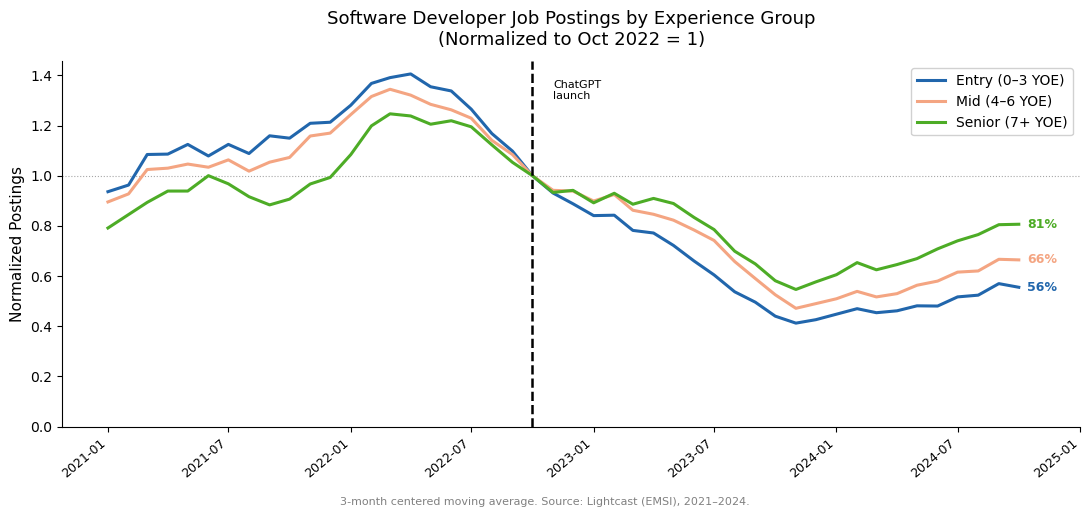

In [198]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

bucket_map = {
    '0-1 YOE': 'Entry (0–3 YOE)',
    '2-3 YOE': 'Entry (0–3 YOE)',
    '4-6 YOE': 'Mid (4–6 YOE)',
    '7-10 YOE': 'Senior (7+ YOE)',
    '11+ YOE':  'Senior (7+ YOE)',
}

swd = (
    df_yoe[df_yoe['soc'] == '15-1252']
    .assign(bucket=lambda d: d['yoe_group'].map(bucket_map))
    .dropna(subset=['bucket'])
    .groupby(['year_month', 'bucket'], as_index=False)['postings'].sum()
)

base_date    = pd.Timestamp('2022-10-01')
cutoff_date  = pd.Timestamp('2024-10-01')
bucket_order = ['Entry (0–3 YOE)', 'Mid (4–6 YOE)', 'Senior (7+ YOE)']
colors       = ['#2166ac', '#f4a582', '#4dac26']

fig, ax = plt.subplots(figsize=(11, 5))

for bucket, color in zip(bucket_order, colors):
    grp = (swd[(swd['bucket'] == bucket) & (swd['year_month'] <= cutoff_date)]
           .sort_values('year_month').reset_index(drop=True).copy())

    # smooth first, then normalize — so all lines = 1.0 at base_date
    grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
    if base_val.empty or base_val.values[0] == 0:
        continue
    grp['norm'] = grp['smooth'] / base_val.values[0]

    ax.plot(grp['year_month'], grp['norm'], label=bucket, color=color, linewidth=2.2, zorder=2)

    ax.annotate(f"{grp['norm'].iloc[-1]:.0%}",
                xy=(grp['year_month'].iloc[-1], grp['norm'].iloc[-1]),
                xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8, zorder=3)
ax.axhline(1.0,       color='gray',  linestyle=':',  linewidth=0.8, alpha=0.7, zorder=1)

ax.text(base_date + pd.DateOffset(months=1), 0.95,
        'ChatGPT\nlaunch', fontsize=8, color='black', va='top',
        transform=ax.get_xaxis_transform())

ax.set_title('Software Developer Job Postings by Experience Group\n(Normalized to Oct 2022 = 1)',
             fontsize=13, pad=12)
ax.set_ylabel('Normalized Postings', fontsize=11)
ax.set_xlabel('')
ax.set_xlim(right=pd.Timestamp('2025-01-01'))
ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10, framealpha=0.9)
sns.despine()

fig.text(0.5, -0.02, '3-month centered moving average. Source: Lightcast (EMSI), 2021–2024.',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/swd_yoe_3bucket.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [199]:
# ── Top 20 AI-exposed occupations in our Lightcast data ───────────────────
lightcast_occs = df_entry['occ_code'].unique()

top20 = (ai_exposure_combined[
            ai_exposure_combined['occ_code'].isin(lightcast_occs)
         ]
         .query('observed_exposure > 0')
         [['occ_code','occupation_title','observed_exposure','gpt4_beta']]
         .sort_values('observed_exposure', ascending=False)
         .head(20)
         .reset_index(drop=True))

top20.index += 1
print(top20.to_string())

   occ_code                                                                              occupation_title  observed_exposure  gpt4_beta
1   15-1251                                                                          Computer Programmers             0.7451   0.941176
2   43-4051                                                              Customer Service Representatives             0.7011   0.566667
3   43-9021                                                                             Data Entry Keyers             0.6707   0.833333
4   29-2072                                                                   Medical Records Specialists             0.6674   0.617647
5   13-1161                                            Market Research Analysts and Marketing Specialists             0.6483   0.500000
6   31-9094                                                                     Medical Transcriptionists             0.6365   0.866667
7   41-4012  Sales Representatives, Wholesale an

In [200]:
# ── Snowflake query: YOE buckets for top 20 AI-exposed occupations ─────────
import snowflake.connector as snow
import os

top20_codes = (ai_exposure_combined[
                   ai_exposure_combined['occ_code'].isin(df_entry['occ_code'].unique())]
               .query('observed_exposure > 0')
               .sort_values('observed_exposure', ascending=False)
               .head(20)['occ_code'].tolist())

in_list = ','.join([f"'{c}'" for c in top20_codes])

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query = f"""
SELECT
    date_trunc('month', p.posted)::date AS year_month,
    p.soc_2021_5                        AS soc,
    CASE
        WHEN p.min_years_experience <= 1  THEN '0-1 YOE'
        WHEN p.min_years_experience <= 3  THEN '2-3 YOE'
        WHEN p.min_years_experience <= 6  THEN '4-6 YOE'
        WHEN p.min_years_experience <= 10 THEN '7-10 YOE'
        WHEN p.min_years_experience > 10  THEN '11+ YOE'
        ELSE 'Not Specified'
    END AS yoe_group,
    COUNT(DISTINCT p.id) AS postings
FROM emsi.us.postings p
WHERE p.soc_2021_5 IN ({in_list})
  AND p.posted BETWEEN '2021-01-01' AND '2025-03-01'
GROUP BY ALL
ORDER BY 1, 2, 3
"""

df_yoe_top20 = pd.read_sql(query, conn)
conn.close()
df_yoe_top20.columns = df_yoe_top20.columns.str.lower()
df_yoe_top20['year_month'] = pd.to_datetime(df_yoe_top20['year_month'])
print(f"Rows: {df_yoe_top20.shape[0]:,}  |  Occupations: {df_yoe_top20['soc'].nunique()}")

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/3115904246.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_yoe_top20 = pd.read_sql(query, conn)


Rows: 5,363  |  Occupations: 20


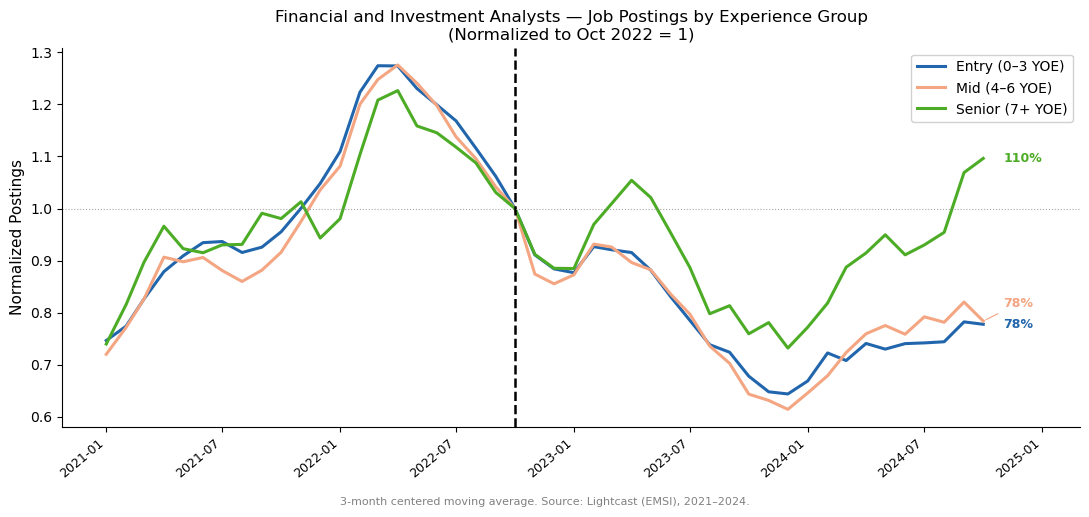

In [201]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

bucket_map = {
    '0-1 YOE': 'Entry (0–3 YOE)',
    '2-3 YOE': 'Entry (0–3 YOE)',
    '4-6 YOE': 'Mid (4–6 YOE)',
    '7-10 YOE': 'Senior (7+ YOE)',
    '11+ YOE':  'Senior (7+ YOE)',
}

base_date    = pd.Timestamp('2022-10-01')
cutoff_date  = pd.Timestamp('2024-10-01')
bucket_order = ['Entry (0–3 YOE)', 'Mid (4–6 YOE)', 'Senior (7+ YOE)']
colors       = ['#2166ac', '#f4a582', '#4dac26']

def spread_labels(vals, min_gap=0.04):
    indexed = sorted(enumerate(vals), key=lambda x: x[1])
    adjusted = [v for _, v in indexed]
    for i in range(1, len(adjusted)):
        if adjusted[i] - adjusted[i-1] < min_gap:
            adjusted[i] = adjusted[i-1] + min_gap
    result = [None] * len(vals)
    for rank, (orig_i, _) in enumerate(indexed):
        result[orig_i] = adjusted[rank]
    return result

df_occ = (
    df_yoe_top20[df_yoe_top20['soc'] == '13-2051']
    .assign(bucket=lambda d: d['yoe_group'].map(bucket_map))
    .dropna(subset=['bucket'])
    .groupby(['year_month', 'bucket'], as_index=False)['postings'].sum()
)

fig, ax = plt.subplots(figsize=(11, 5))

end_vals = []
last_x   = None

for bucket, color in zip(bucket_order, colors):
    grp = (df_occ[(df_occ['bucket'] == bucket) & (df_occ['year_month'] <= cutoff_date)]
           .sort_values('year_month').reset_index(drop=True).copy())
    if grp.empty:
        continue
    grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
    if base_val.empty or base_val.values[0] == 0:
        continue
    grp['norm'] = grp['smooth'] / base_val.values[0]
    ax.plot(grp['year_month'], grp['norm'], label=bucket, color=color, linewidth=2.2)
    end_vals.append((grp['norm'].iloc[-1], color, f"{grp['norm'].iloc[-1]:.0%}"))
    last_x = grp['year_month'].iloc[-1]

if end_vals and last_x:
    raw_ys = [v[0] for v in end_vals]
    adj_ys = spread_labels(raw_ys)
    for (orig_y, color, label), adj_y in zip(end_vals, adj_ys):
        ax.annotate(label,
                    xy=(last_x, orig_y),
                    xytext=(last_x + pd.DateOffset(months=1), adj_y),
                    fontsize=9, color=color, fontweight='bold', va='center',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8) if abs(adj_y - orig_y) > 0.01 else None)

ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
ax.set_title('Financial and Investment Analysts — Job Postings by Experience Group\n(Normalized to Oct 2022 = 1)', fontsize=12)
ax.set_ylabel('Normalized Postings', fontsize=11)
ax.set_xlabel('')
ax.set_xlim(right=pd.Timestamp('2025-03-01'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10, framealpha=0.9)
sns.despine()

fig.text(0.5, -0.02, '3-month centered moving average. Source: Lightcast (EMSI), 2021–2024.',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/yoe_finanalysts.png',
            dpi=150, bbox_inches='tight')
plt.show()

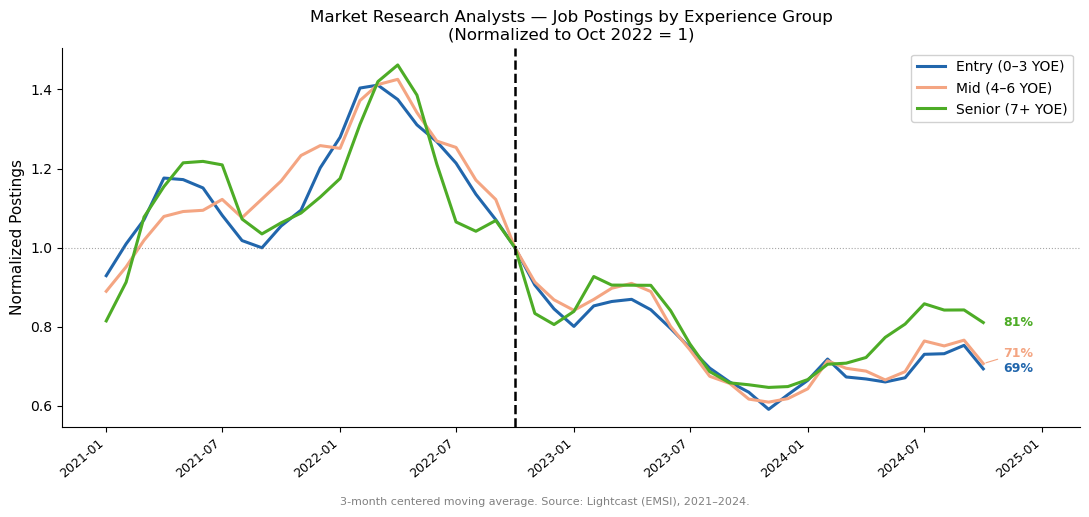

In [202]:
# Appendix: Market Research Analysts and Marketing Specialists (13-1161)
df_occ_mr = (
    df_yoe_top20[df_yoe_top20['soc'] == '13-1161']
    .assign(bucket=lambda d: d['yoe_group'].map(bucket_map))
    .dropna(subset=['bucket'])
    .groupby(['year_month', 'bucket'], as_index=False)['postings'].sum()
)

fig, ax = plt.subplots(figsize=(11, 5))

end_vals = []
last_x   = None

for bucket, color in zip(bucket_order, colors):
    grp = (df_occ_mr[(df_occ_mr['bucket'] == bucket) & (df_occ_mr['year_month'] <= cutoff_date)]
           .sort_values('year_month').reset_index(drop=True).copy())
    if grp.empty:
        continue
    grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
    if base_val.empty or base_val.values[0] == 0:
        continue
    grp['norm'] = grp['smooth'] / base_val.values[0]
    ax.plot(grp['year_month'], grp['norm'], label=bucket, color=color, linewidth=2.2)
    end_vals.append((grp['norm'].iloc[-1], color, f"{grp['norm'].iloc[-1]:.0%}"))
    last_x = grp['year_month'].iloc[-1]

if end_vals and last_x:
    raw_ys = [v[0] for v in end_vals]
    adj_ys = spread_labels(raw_ys)
    for (orig_y, color, label), adj_y in zip(end_vals, adj_ys):
        ax.annotate(label,
                    xy=(last_x, orig_y),
                    xytext=(last_x + pd.DateOffset(months=1), adj_y),
                    fontsize=9, color=color, fontweight='bold', va='center',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8) if abs(adj_y - orig_y) > 0.01 else None)

ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
ax.set_title('Market Research Analysts — Job Postings by Experience Group\n(Normalized to Oct 2022 = 1)', fontsize=12)
ax.set_ylabel('Normalized Postings', fontsize=11)
ax.set_xlabel('')
ax.set_xlim(right=pd.Timestamp('2025-03-01'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10, framealpha=0.9)
sns.despine()

fig.text(0.5, -0.02, '3-month centered moving average. Source: Lightcast (EMSI), 2021–2024.',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/yoe_mktresearch.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [203]:
# ── Query: low-exposure contrast occupations ──────────────────────────────
low_exp_meta = {
    '35-2014': 'Cooks, Restaurant',
}

in_list_low = ','.join([f"'{c}'" for c in low_exp_meta])

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query_low = f"""
SELECT
    date_trunc('month', p.posted)::date AS year_month,
    p.soc_2021_5                        AS soc,
    CASE
        WHEN p.min_years_experience <= 1  THEN '0-1 YOE'
        WHEN p.min_years_experience <= 3  THEN '2-3 YOE'
        WHEN p.min_years_experience <= 6  THEN '4-6 YOE'
        WHEN p.min_years_experience <= 10 THEN '7-10 YOE'
        WHEN p.min_years_experience > 10  THEN '11+ YOE'
        ELSE 'Not Specified'
    END AS yoe_group,
    COUNT(DISTINCT p.id) AS postings
FROM emsi.us.postings p
WHERE p.soc_2021_5 IN ({in_list_low})
  AND p.posted BETWEEN '2021-01-01' AND '2025-03-01'
GROUP BY ALL
ORDER BY 1, 2, 3
"""

df_yoe_lowexp = pd.read_sql(query_low, conn)
conn.close()
df_yoe_lowexp.columns = df_yoe_lowexp.columns.str.lower()
df_yoe_lowexp['year_month'] = pd.to_datetime(df_yoe_lowexp['year_month'])
print(f"Rows: {df_yoe_lowexp.shape[0]:,}  |  Occupations found: {df_yoe_lowexp['soc'].nunique()}")
print("SOCs returned:", df_yoe_lowexp['soc'].unique())

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1108452342.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_yoe_lowexp = pd.read_sql(query_low, conn)


Rows: 294  |  Occupations found: 1
SOCs returned: ['35-2014']


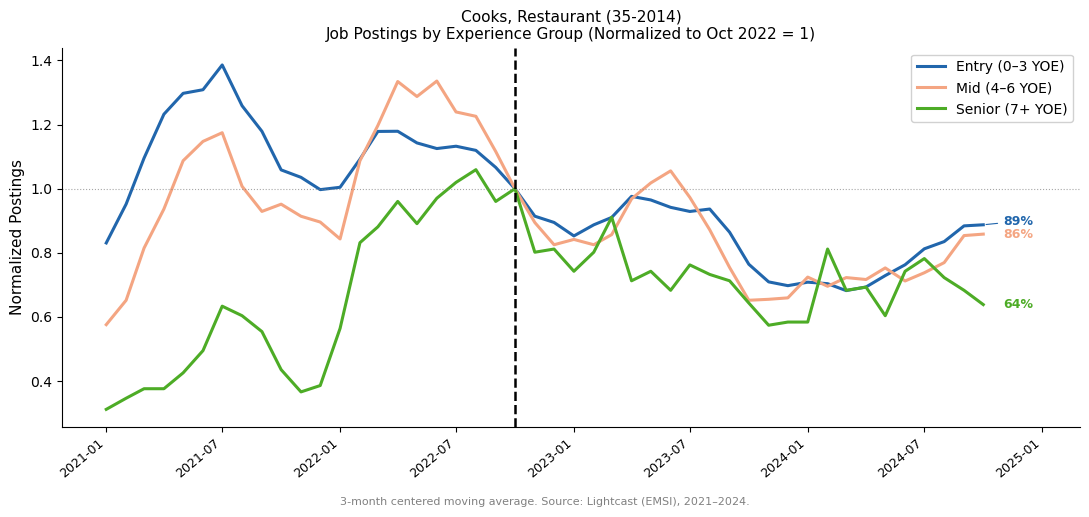

In [204]:
# ── Loop: YOE bucket charts for 3 low-exposure occupations ────────────────
bucket_map   = {
    '0-1 YOE': 'Entry (0–3 YOE)',
    '2-3 YOE': 'Entry (0–3 YOE)',
    '4-6 YOE': 'Mid (4–6 YOE)',
    '7-10 YOE': 'Senior (7+ YOE)',
    '11+ YOE':  'Senior (7+ YOE)',
}
bucket_order = ['Entry (0–3 YOE)', 'Mid (4–6 YOE)', 'Senior (7+ YOE)']
colors       = ['#2166ac', '#f4a582', '#4dac26']   # blue, salmon, green
base_date    = pd.Timestamp('2022-10-01')
cutoff_date  = pd.Timestamp('2024-10-01')

for soc, title in low_exp_meta.items():
    df_occ = (
        df_yoe_lowexp[df_yoe_lowexp['soc'] == soc]
        .assign(bucket=lambda d: d['yoe_group'].map(bucket_map))
        .dropna(subset=['bucket'])
        .groupby(['year_month', 'bucket'], as_index=False)['postings'].sum()
    )
    if df_occ.empty:
        print(f"SKIP {soc} ({title}) — no data in Lightcast"); continue

    fig, ax = plt.subplots(figsize=(11, 5))
    end_vals = []
    last_x   = None

    for bucket, color in zip(bucket_order, colors):
        grp = (df_occ[(df_occ['bucket'] == bucket) & (df_occ['year_month'] <= cutoff_date)]
               .sort_values('year_month').reset_index(drop=True).copy())
        if grp.empty: continue
        grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
        base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
        if base_val.empty or base_val.values[0] == 0: continue
        grp['norm'] = grp['smooth'] / base_val.values[0]
        ax.plot(grp['year_month'], grp['norm'], label=bucket, color=color, linewidth=2.2)
        end_vals.append((grp['norm'].iloc[-1], color, f"{grp['norm'].iloc[-1]:.0%}"))
        last_x = grp['year_month'].iloc[-1]

    if end_vals and last_x:
        raw_ys = [v[0] for v in end_vals]
        adj_ys = spread_labels(raw_ys)
        for (orig_y, color, lbl), adj_y in zip(end_vals, adj_ys):
            ax.annotate(lbl,
                        xy=(last_x, orig_y),
                        xytext=(last_x + pd.DateOffset(months=1), adj_y),
                        fontsize=9, color=color, fontweight='bold', va='center',
                        arrowprops=dict(arrowstyle='-', color=color, lw=0.8) if abs(adj_y - orig_y) > 0.01 else None)

    ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_title(f'{title} ({soc})\nJob Postings by Experience Group (Normalized to Oct 2022 = 1)',
                 fontsize=11)
    ax.set_ylabel('Normalized Postings', fontsize=11)
    ax.set_xlabel('')
    ax.set_xlim(right=pd.Timestamp('2025-03-01'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.xticks(rotation=40, ha='right', fontsize=9)
    ax.legend(fontsize=10, framealpha=0.9)
    sns.despine()
    fig.text(0.5, -0.02, '3-month centered moving average. Source: Lightcast (EMSI), 2021–2024.',
             ha='center', fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

In [205]:
import snowflake.connector as snow
import os

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query = """
SELECT
    date_trunc('month', p.posted)::date AS year_month,
    p.soc_2021_5                        AS occ_code,
    COUNT(DISTINCT p.id)                AS postings
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2024-10-31'
  AND p.soc_2021_5 IS NOT NULL
GROUP BY ALL
ORDER BY 1, 2
"""

df_all = pd.read_sql(query, conn)
conn.close()

df_all.columns  = df_all.columns.str.lower()
df_all['year_month'] = pd.to_datetime(df_all['year_month'])
print(f"Rows: {df_all.shape[0]:,}  |  Occupations: {df_all['occ_code'].nunique()}")

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/4271867622.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql(query, conn)


Rows: 34,914  |  Occupations: 767


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1947748150.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year_month', 'quartile'], as_index=False)['postings'].sum())


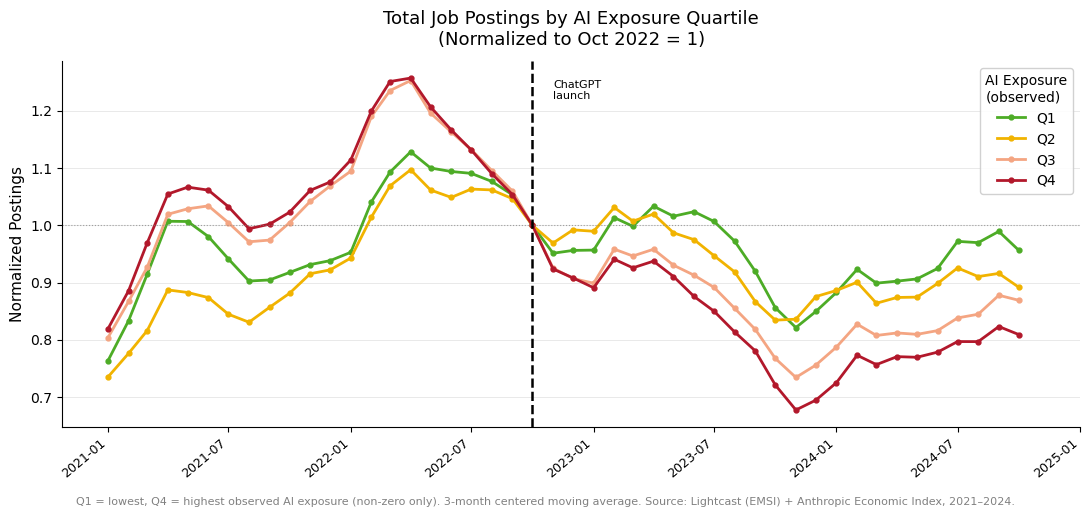

In [206]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Assign observed_exposure quartiles (non-zero only) ─────────────────────
exposure_nz = (ai_exposure_combined[['occ_code', 'observed_exposure']]
               .dropna()
               .query('observed_exposure > 0')
               .copy())
exposure_nz['quartile'] = pd.qcut(exposure_nz['observed_exposure'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# ── Merge postings with quartile labels ────────────────────────────────────
df_q = (df_all
        .merge(exposure_nz[['occ_code', 'quartile']], on='occ_code', how='inner')
        .groupby(['year_month', 'quartile'], as_index=False)['postings'].sum())

# ── Smooth then normalize to Oct 2022 = 1 per quartile ────────────────────
base_date      = pd.Timestamp('2022-10-01')
quartile_order = ['Q1', 'Q2', 'Q3', 'Q4']
colors         = ['#4dac26', '#f1b300', '#f4a582', '#b2182b']

fig, ax = plt.subplots(figsize=(11, 5))

for q, color in zip(quartile_order, colors):
    grp = (df_q[df_q['quartile'] == q]
           .sort_values('year_month').reset_index(drop=True).copy())
    grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
    if base_val.empty or base_val.values[0] == 0:
        continue
    grp['norm'] = grp['smooth'] / base_val.values[0]
    ax.plot(grp['year_month'], grp['norm'],
            label=q, color=color, linewidth=2.0,
            marker='o', markersize=3.5, zorder=2)

ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8, zorder=3)
ax.axhline(1.0,       color='gray',  linestyle=':',  linewidth=0.8, alpha=0.7)

ax.text(base_date + pd.DateOffset(months=1), 0.95,
        'ChatGPT\nlaunch', fontsize=8, color='black', va='top',
        transform=ax.get_xaxis_transform())

ax.set_title('Total Job Postings by AI Exposure Quartile\n(Normalized to Oct 2022 = 1)',
             fontsize=13, pad=12)
ax.set_ylabel('Normalized Postings', fontsize=11)
ax.set_xlabel('')
ax.set_xlim(right=pd.Timestamp('2025-01-01'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.legend(title='AI Exposure\n(observed)', fontsize=10, framealpha=0.9)
ax.grid(axis='y', linewidth=0.4, alpha=0.5)
sns.despine()

fig.text(0.5, -0.02,
         'Q1 = lowest, Q4 = highest observed AI exposure (non-zero only). 3-month centered moving average. Source: Lightcast (EMSI) + Anthropic Economic Index, 2021–2024.',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/postings_by_quartile_observed.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [207]:
# ── Entry-level share by quartile: Snowflake query (3 definitions) ────────
import snowflake.connector as snow
import os

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query = """
SELECT
    date_trunc('month', p.posted)::date    AS year_month,
    p.soc_2021_5                           AS occ_code,
    COUNT(DISTINCT p.id)                   AS total_postings,

    -- Main def: YOE <= 2 OR (Junior + NULL YOE), edu <= Bachelor's
    COUNT(DISTINCT CASE
        WHEN (p.min_years_experience <= 2
              OR (p.job_seniority_name = 'Junior' AND p.min_years_experience IS NULL))
        AND  (p.min_edulevels_name IS NULL
              OR p.min_edulevels_name NOT IN ('Master''s Degree','Doctoral or Professional Degree'))
        THEN p.id END)                     AS entry_main,

    -- Strict YOE < 2 only (no NULL handling)
    COUNT(DISTINCT CASE
        WHEN p.min_years_experience < 2
        AND  (p.min_edulevels_name IS NULL
              OR p.min_edulevels_name NOT IN ('Master''s Degree','Doctoral or Professional Degree'))
        THEN p.id END)                     AS entry_lt2,

    -- Burning Glass style: YOE < 3 only (no NULL handling)
    COUNT(DISTINCT CASE
        WHEN p.min_years_experience < 3
        AND  (p.min_edulevels_name IS NULL
              OR p.min_edulevels_name NOT IN ('Master''s Degree','Doctoral or Professional Degree'))
        THEN p.id END)                     AS entry_lt3

FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2024-10-31'
  AND p.soc_2021_5 IS NOT NULL
GROUP BY ALL
ORDER BY 1, 2
"""

df_entry = pd.read_sql(query, conn)
conn.close()

df_entry.columns     = df_entry.columns.str.lower()
df_entry['year_month'] = pd.to_datetime(df_entry['year_month'])
tot = df_entry['total_postings'].sum()
print(f"Rows: {df_entry.shape[0]:,}  |  Occupations: {df_entry['occ_code'].nunique()}")
print(f"Entry share — main: {df_entry['entry_main'].sum()/tot:.1%}  |  <2 YOE: {df_entry['entry_lt2'].sum()/tot:.1%}  |  <3 YOE: {df_entry['entry_lt3'].sum()/tot:.1%}")

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/3452734063.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_entry = pd.read_sql(query, conn)


Rows: 34,914  |  Occupations: 767
Entry share — main: 26.8%  |  <2 YOE: 15.1%  |  <3 YOE: 24.6%


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1274512511.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year_month', 'quartile'], as_index=False)


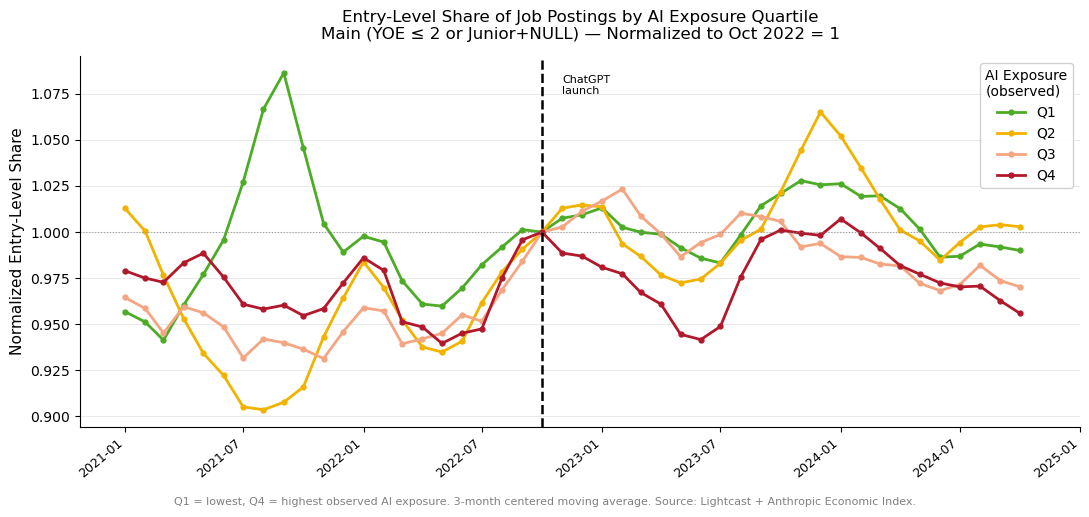

Saved → entry_share_by_quartile_main.png


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1274512511.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year_month', 'quartile'], as_index=False)


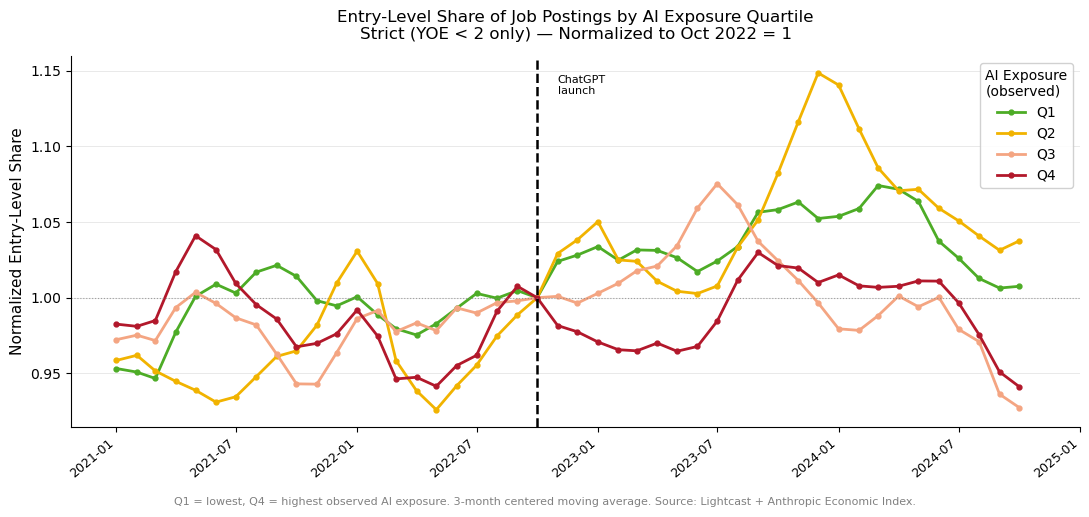

Saved → entry_share_by_quartile_lt2.png


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1274512511.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['year_month', 'quartile'], as_index=False)


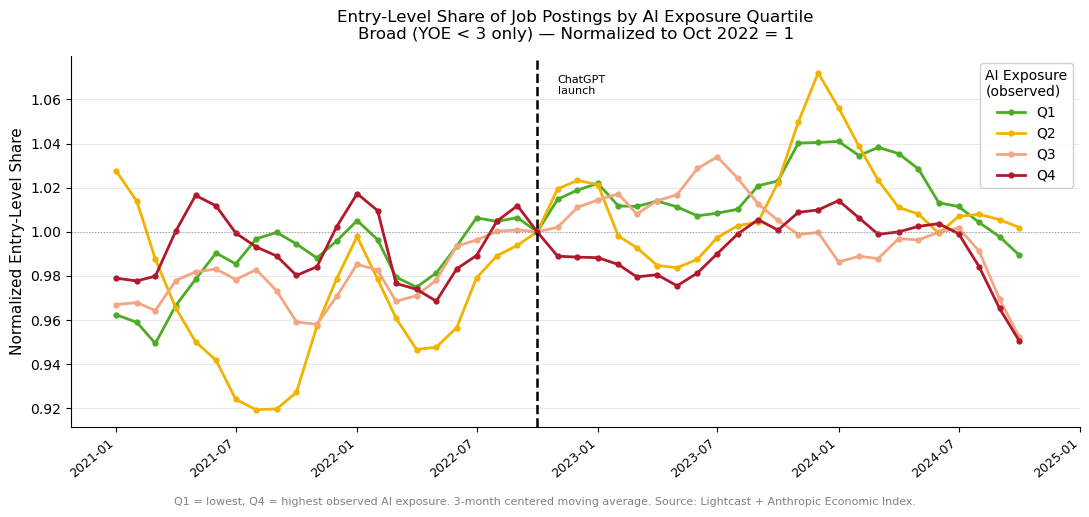

Saved → entry_share_by_quartile_lt3.png


In [208]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Assign observed_exposure quartiles (non-zero only) ─────────────────────
exposure_nz = (ai_exposure_combined[['occ_code', 'observed_exposure']]
               .dropna().query('observed_exposure > 0').copy())
exposure_nz['quartile'] = pd.qcut(exposure_nz['observed_exposure'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

df_merged = df_entry.merge(exposure_nz[['occ_code', 'quartile']], on='occ_code', how='inner')

definitions = [
    ('entry_main', 'Main (YOE ≤ 2 or Junior+NULL)',  'entry_share_by_quartile_main.png'),
    ('entry_lt2',  'Strict (YOE < 2 only)',           'entry_share_by_quartile_lt2.png'),
    ('entry_lt3',  'Broad (YOE < 3 only)',            'entry_share_by_quartile_lt3.png'),
]

base_date      = pd.Timestamp('2022-10-01')
quartile_order = ['Q1', 'Q2', 'Q3', 'Q4']
colors         = ['#4dac26', '#f1b300', '#f4a582', '#b2182b']

for col, label, fname in definitions:
    df_q = (df_merged
            .groupby(['year_month', 'quartile'], as_index=False)
            [[col, 'total_postings']].sum())
    df_q['entry_share'] = df_q[col] / df_q['total_postings']

    fig, ax = plt.subplots(figsize=(11, 5))

    for q, color in zip(quartile_order, colors):
        grp = (df_q[df_q['quartile'] == q]
               .sort_values('year_month').reset_index(drop=True).copy())
        grp['smooth'] = grp['entry_share'].rolling(3, center=True, min_periods=1).mean()
        base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
        if base_val.empty or base_val.values[0] == 0:
            continue
        grp['norm'] = grp['smooth'] / base_val.values[0]
        ax.plot(grp['year_month'], grp['norm'],
                label=q, color=color, linewidth=2.0,
                marker='o', markersize=3.5, zorder=2)

    ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8, zorder=3)
    ax.axhline(1.0,       color='gray',  linestyle=':',  linewidth=0.8, alpha=0.7)
    ax.text(base_date + pd.DateOffset(months=1), 0.95,
            'ChatGPT\nlaunch', fontsize=8, color='black', va='top',
            transform=ax.get_xaxis_transform())

    ax.set_title(f'Entry-Level Share of Job Postings by AI Exposure Quartile\n{label} — Normalized to Oct 2022 = 1',
                 fontsize=12, pad=12)
    ax.set_ylabel('Normalized Entry-Level Share', fontsize=11)
    ax.set_xlabel('')
    ax.set_xlim(right=pd.Timestamp('2025-01-01'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.xticks(rotation=40, ha='right', fontsize=9)
    ax.legend(title='AI Exposure\n(observed)', fontsize=10, framealpha=0.9)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    sns.despine()
    fig.text(0.5, -0.02,
             'Q1 = lowest, Q4 = highest observed AI exposure. 3-month centered moving average. Source: Lightcast + Anthropic Economic Index.',
             ha='center', fontsize=8, color='gray')
    plt.tight_layout()
    plt.savefig(f'/Users/khaliun/Documents/USF/ECON696/writeup/figures/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")

In [209]:
# ── Canaries-style figure: query all occupations × YOE bucket × month ────
import snowflake.connector as snow
import os

conn = snow.connect(
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    account="avb99459.us-east-1",
    warehouse="OPPORTUNITYATWORK_WH"
)

query_yoe_all = """
SELECT
    date_trunc('month', p.posted)::date AS year_month,
    p.soc_2021_5                        AS soc,
    CASE
        WHEN p.min_years_experience <= 3 THEN 'Entry (0–3 YOE)'
        WHEN p.min_years_experience <= 6 THEN 'Mid (4–6 YOE)'
        WHEN p.min_years_experience >  6 THEN 'Senior (7+ YOE)'
    END AS yoe_bucket,
    COUNT(DISTINCT p.id) AS postings
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2025-03-01'
  AND p.soc_2021_5 IS NOT NULL
  AND p.min_years_experience IS NOT NULL
  AND p.min_edulevels_name IN ('No Education Listed', 'High school or GED', 'Associate degree', 'Bachelor''''s Degree')
GROUP BY ALL
ORDER BY 1, 2, 3
"""

df_yoe_all = pd.read_sql(query_yoe_all, conn)
conn.close()
df_yoe_all.columns = df_yoe_all.columns.str.lower()
df_yoe_all['year_month'] = pd.to_datetime(df_yoe_all['year_month'])
print(f"Rows: {df_yoe_all.shape[0]:,}  |  Occupations: {df_yoe_all['soc'].nunique()}")


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/1831168202.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_yoe_all = pd.read_sql(query_yoe_all, conn)


Rows: 100,512  |  Occupations: 765


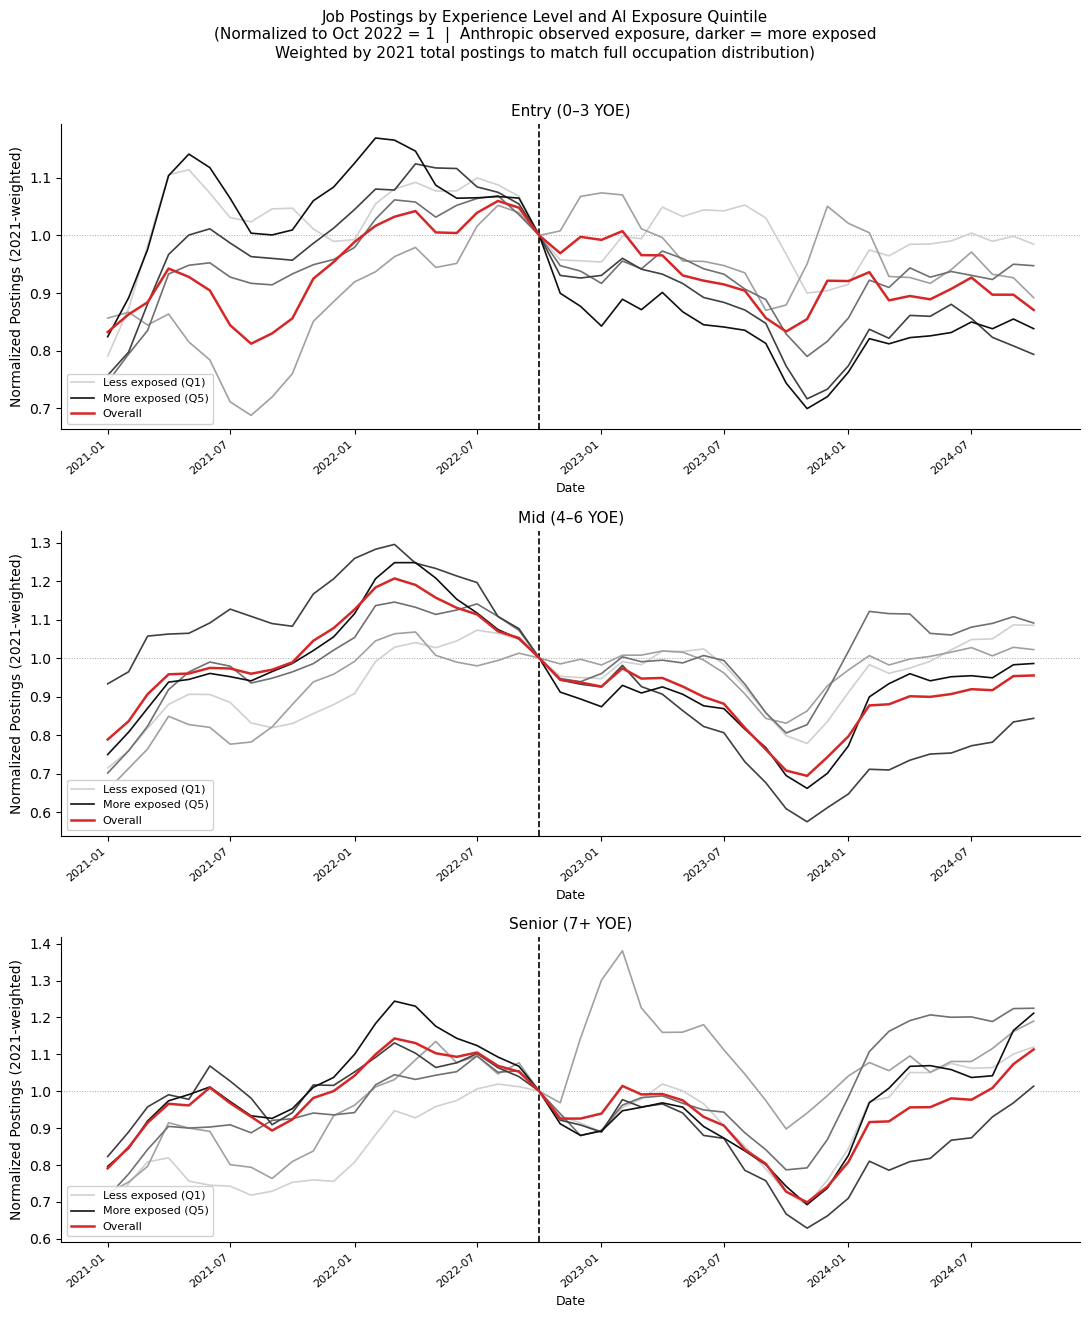

In [210]:
# ── Canaries-style panel plot: observed_exposure (Anthropic index) version ─
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

# ── 2021 weights from FULL universe ───────────────────────────────────────
weights_2021 = (df_all[df_all['year_month'].dt.year == 2021]
                .groupby('occ_code', as_index=False)['postings'].sum()
                .rename(columns={'postings': 'w_2021', 'occ_code': 'soc'}))
weights_2021['w_2021_pct'] = weights_2021['w_2021'] / weights_2021['w_2021'].sum()

# ── observed_exposure quintiles (non-zero only) ───────────────────────────
obs_q = (ai_exposure_combined[['occ_code', 'observed_exposure']]
         .dropna()
         .query('observed_exposure > 0')
         .copy())
obs_q['quintile'] = pd.qcut(obs_q['observed_exposure'], 5,
                             labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

# ── Merge YOE data with quintile labels AND full-universe weights ──────────
df_merged_obs = (df_yoe_all
                 .merge(obs_q[['occ_code', 'quintile']],
                        left_on='soc', right_on='occ_code', how='inner')
                 .merge(weights_2021[['soc', 'w_2021_pct']], on='soc', how='left'))
df_merged_obs['wt_postings'] = df_merged_obs['postings'] * df_merged_obs['w_2021_pct']

base_date      = pd.Timestamp('2022-10-01')
cutoff_date    = pd.Timestamp('2024-10-01')
buckets        = ['Entry (0\u20133 YOE)', 'Mid (4\u20136 YOE)', 'Senior (7+ YOE)']
quintile_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
grays          = ['#d0d0d0', '#a0a0a0', '#707070', '#404040', '#101010']

fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharey=False)

for ax, bucket in zip(axes, buckets):
    df_b = df_merged_obs[
        (df_merged_obs['yoe_bucket'] == bucket) &
        (df_merged_obs['year_month'] <= cutoff_date)
    ]

    # Overall line (red)
    overall = (df_b.groupby('year_month', as_index=False)['wt_postings'].sum()
               .sort_values('year_month').reset_index(drop=True))
    overall['smooth'] = overall['wt_postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = overall.loc[overall['year_month'] == base_date, 'smooth']
    if not base_val.empty and base_val.values[0] != 0:
        overall['norm'] = overall['smooth'] / base_val.values[0]
        ax.plot(overall['year_month'], overall['norm'],
                color='#d62728', linewidth=1.8, zorder=5)

    # Quintile lines
    for q, color in zip(quintile_order, grays):
        grp = (df_b[df_b['quintile'] == q]
               .groupby('year_month', as_index=False)['wt_postings'].sum()
               .sort_values('year_month').reset_index(drop=True))
        if grp.empty: continue
        grp['smooth'] = grp['wt_postings'].rolling(3, center=True, min_periods=1).mean()
        base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
        if base_val.empty or base_val.values[0] == 0: continue
        grp['norm'] = grp['smooth'] / base_val.values[0]
        ax.plot(grp['year_month'], grp['norm'],
                color=color, linewidth=1.2, zorder=3)

    ax.axvline(base_date, color='black', linestyle='--', linewidth=1.2)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.set_title(bucket, fontsize=11)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Normalized Postings (2021-weighted)', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=8)
    sns.despine(ax=ax)

    legend_els = [
        Line2D([0], [0], color=grays[0],  lw=1.2, label='Less exposed (Q1)'),
        Line2D([0], [0], color=grays[-1], lw=1.2, label='More exposed (Q5)'),
        Line2D([0], [0], color='#d62728', lw=1.8, label='Overall'),
    ]
    ax.legend(handles=legend_els, fontsize=8, framealpha=0.9, loc='lower left')

fig.suptitle(
    'Job Postings by Experience Level and AI Exposure Quintile\n'
    '(Normalized to Oct 2022 = 1  |  Anthropic observed exposure, darker = more exposed\n'
    'Weighted by 2021 total postings to match full occupation distribution)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/canaries_style_yoe_observed.png',
            dpi=150, bbox_inches='tight')
plt.show()


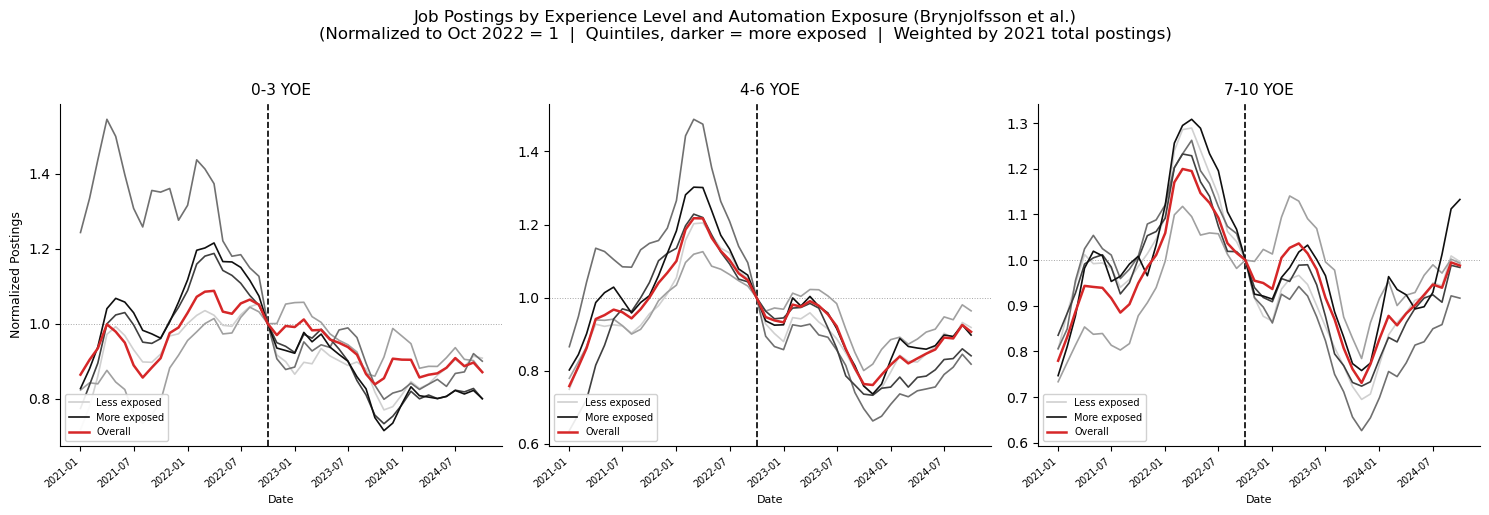

Saved → canaries_fact3_automation.png


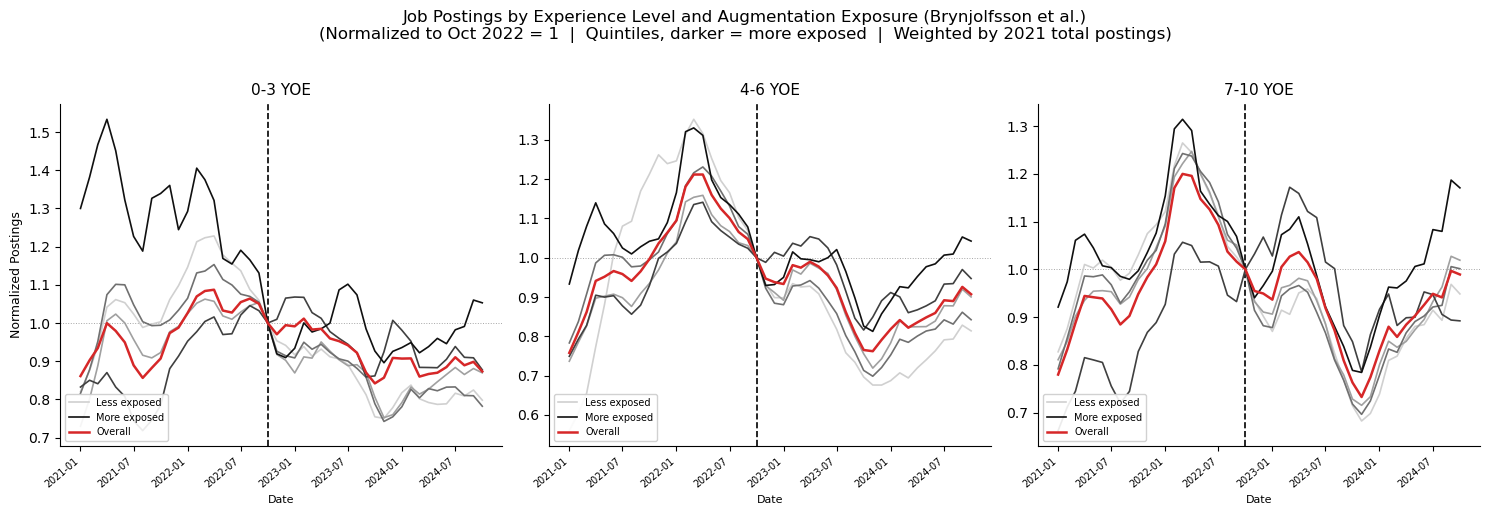

Saved → canaries_fact3_augmentation.png


In [211]:
# ── Canaries Fact 3: automation & augmentation 1×3 grids (no 11+ YOE) ────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

weights_2021 = (df_all[df_all['year_month'].dt.year == 2021]
                .groupby('occ_code', as_index=False)['postings'].sum()
                .rename(columns={'postings': 'w_2021', 'occ_code': 'soc'}))
weights_2021['w_2021_pct'] = weights_2021['w_2021'] / weights_2021['w_2021'].sum()

base_date, cutoff_date = pd.Timestamp('2022-10-01'), pd.Timestamp('2024-10-01')
bucket_order   = ['0-3 YOE', '4-6 YOE', '7-10 YOE']
quintile_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
grays          = ['#d0d0d0', '#a0a0a0', '#707070', '#404040', '#101010']

measures = [
    ('automation_weighted_ratio',   'Automation Exposure (Brynjolfsson et al.)',   'canaries_fact3_automation.png'),
    ('augmentation_weighted_ratio', 'Augmentation Exposure (Brynjolfsson et al.)', 'canaries_fact3_augmentation.png'),
]

for col, label, fname in measures:
    exp_q = ai_exposure_combined[['occ_code', col]].dropna().copy()
    exp_q = exp_q[exp_q[col] > 0]
    exp_q['quintile'] = pd.qcut(exp_q[col], 5, labels=['Q1','Q2','Q3','Q4','Q5'])

    df_merged = (df_yoe_occ
                 .merge(exp_q[['occ_code','quintile']], left_on='soc', right_on='occ_code', how='inner')
                 .merge(weights_2021[['soc','w_2021_pct']], on='soc', how='left'))
    df_merged['wt_postings'] = df_merged['postings'] * df_merged['w_2021_pct']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for ax, bucket in zip(axes, bucket_order):
        df_b = df_merged[(df_merged['yoe_bucket'] == bucket) &
                         (df_merged['year_month'] <= cutoff_date)]

        overall = (df_b.groupby('year_month', as_index=False)['wt_postings'].sum()
                   .sort_values('year_month').reset_index(drop=True))
        overall['smooth'] = overall['wt_postings'].rolling(3, center=True, min_periods=1).mean()
        base_val = overall.loc[overall['year_month'] == base_date, 'smooth']
        if not base_val.empty and base_val.values[0] != 0:
            overall['norm'] = overall['smooth'] / base_val.values[0]
            ax.plot(overall['year_month'], overall['norm'], color='#d62728', linewidth=1.8, zorder=5)

        for q, color in zip(quintile_order, grays):
            grp = (df_b[df_b['quintile'] == q]
                   .groupby('year_month', as_index=False)['wt_postings'].sum()
                   .sort_values('year_month').reset_index(drop=True))
            if grp.empty: continue
            grp['smooth'] = grp['wt_postings'].rolling(3, center=True, min_periods=1).mean()
            base_val = grp.loc[grp['year_month'] == base_date, 'smooth']
            if base_val.empty or base_val.values[0] == 0: continue
            grp['norm'] = grp['smooth'] / base_val.values[0]
            ax.plot(grp['year_month'], grp['norm'], color=color, linewidth=1.2, zorder=3)

        ax.axvline(base_date, color='black', linestyle='--', linewidth=1.2)
        ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.7, alpha=0.7)
        ax.set_title(bucket, fontsize=11)
        ax.set_xlabel('Date', fontsize=8)
        ax.set_ylabel('Normalized Postings' if ax is axes[0] else '', fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=7)
        sns.despine(ax=ax)
        ax.legend(handles=[
            Line2D([0],[0], color=grays[0],  lw=1.2, label='Less exposed'),
            Line2D([0],[0], color=grays[-1], lw=1.2, label='More exposed'),
            Line2D([0],[0], color='#d62728', lw=1.8, label='Overall'),
        ], fontsize=7, framealpha=0.9, loc='lower left')

    fig.suptitle(
        f'Job Postings by Experience Level and {label}\n'
        '(Normalized to Oct 2022 = 1  |  Quintiles, darker = more exposed  |  Weighted by 2021 total postings)',
        fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'/Users/khaliun/Documents/USF/ECON696/writeup/figures/{fname}',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")


In [212]:
# ── Fact 2 analog: postings by YOE bucket, normalized to 2021 avg ───────
import snowflake.connector as snow, os

conn = snow.connect(user=os.environ["SNOWFLAKE_USER"], password=os.environ["SNOWFLAKE_PASSWORD"],
                    account="avb99459.us-east-1", warehouse="OPPORTUNITYATWORK_WH")

df_fact2 = pd.read_sql("""
SELECT date_trunc('month', p.posted)::date AS year_month,
       CASE WHEN p.min_years_experience <= 1  THEN '0-1 YOE'
            WHEN p.min_years_experience <= 3  THEN '2-3 YOE'
            WHEN p.min_years_experience <= 6  THEN '4-6 YOE'
            WHEN p.min_years_experience <= 10 THEN '7-10 YOE'
            WHEN p.min_years_experience > 10  THEN '11+ YOE'
       END AS yoe_bucket,
       COUNT(DISTINCT p.id) AS postings
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2025-03-01'
  AND p.min_years_experience IS NOT NULL
GROUP BY ALL
HAVING yoe_bucket IS NOT NULL
ORDER BY 1, 2
""", conn)
conn.close()
df_fact2.columns = df_fact2.columns.str.lower()
df_fact2['year_month'] = pd.to_datetime(df_fact2['year_month'])
print(df_fact2['yoe_bucket'].value_counts())
print(f'Months: {df_fact2["year_month"].nunique()}')

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/3131222660.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fact2 = pd.read_sql("""


yoe_bucket
0-1 YOE     51
11+ YOE     51
2-3 YOE     51
4-6 YOE     51
7-10 YOE    51
Name: count, dtype: int64
Months: 51


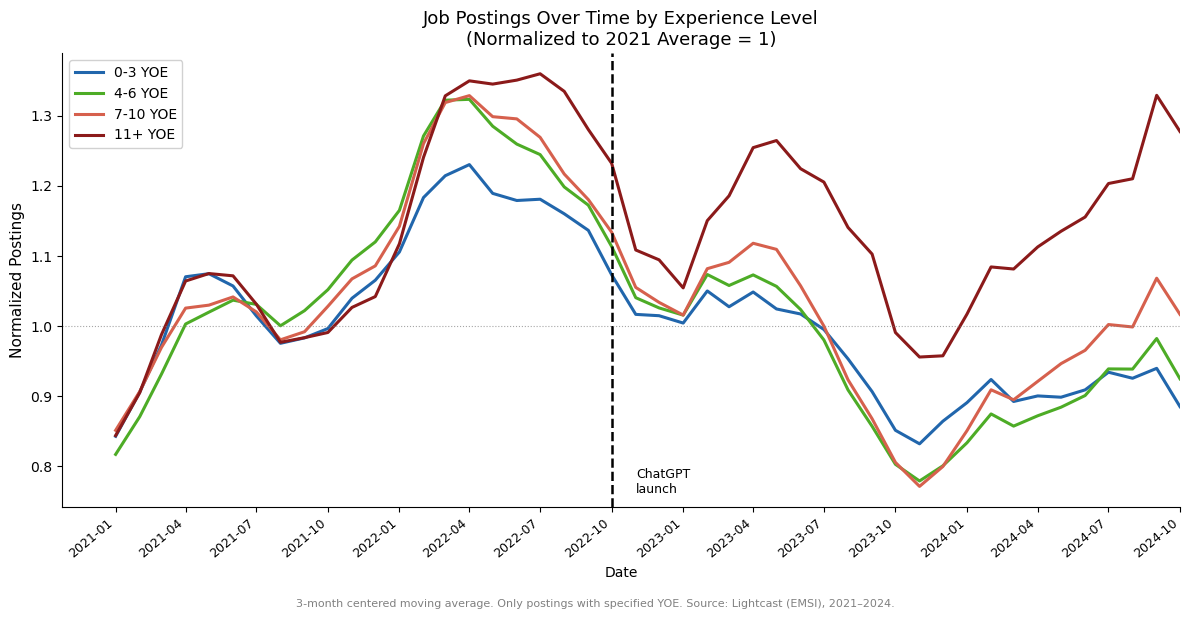

In [213]:
# ── Fact 2 analog: 4-bucket version (0-3 combined) ─────────────────────
import matplotlib.pyplot as plt, matplotlib.dates as mdates, seaborn as sns

remap = {'0-1 YOE': '0-3 YOE', '2-3 YOE': '0-3 YOE',
         '4-6 YOE': '4-6 YOE', '7-10 YOE': '7-10 YOE', '11+ YOE': '11+ YOE'}

df_4b = (df_fact2
         .assign(bucket=lambda d: d['yoe_bucket'].map(remap))
         .groupby(['year_month', 'bucket'], as_index=False)['postings'].sum())

bucket_order = ['0-3 YOE', '4-6 YOE', '7-10 YOE', '11+ YOE']
colors       = ['#2166ac', '#4dac26', '#d6604d', '#8b1a1a']
base_date    = pd.Timestamp('2022-10-01')
cutoff_date  = pd.Timestamp('2024-10-01')

fig, ax = plt.subplots(figsize=(12, 6))

for bucket, color in zip(bucket_order, colors):
    grp = (df_4b[df_4b['bucket'] == bucket]
           .sort_values('year_month').copy())
    if grp.empty: continue
    grp['smooth'] = grp['postings'].rolling(3, center=True, min_periods=1).mean()
    base_val = grp[grp['year_month'].dt.year == 2021]['smooth'].mean()
    if base_val == 0: continue
    grp['norm'] = grp['smooth'] / base_val
    grp = grp[grp['year_month'] <= cutoff_date]
    ax.plot(grp['year_month'], grp['norm'], label=bucket, color=color, linewidth=2.2)

ax.axvline(base_date, color='black', linestyle='--', linewidth=1.8)
ax.text(base_date + pd.DateOffset(months=1), ax.get_ylim()[0] + 0.02,
        'ChatGPT\nlaunch', fontsize=9, color='black')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
ax.set_title('Job Postings Over Time by Experience Level\n'
             '(Normalized to 2021 Average = 1)',
             fontsize=13)
ax.set_ylabel('Normalized Postings', fontsize=11)
ax.set_xlabel('Date', fontsize=10)
ax.set_xlim(right=cutoff_date)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=10, framealpha=0.9, loc='upper left')
sns.despine()
fig.text(0.5, -0.02,
         '3-month centered moving average. Only postings with specified YOE. Source: Lightcast (EMSI), 2021–2024.',
         ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/slide_figures/postings_by_yoe_fact2_4bucket.png',
            dpi=150, bbox_inches='tight')
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/postings_by_yoe_fact2_4bucket.png',
            dpi=150, bbox_inches='tight')
plt.show()

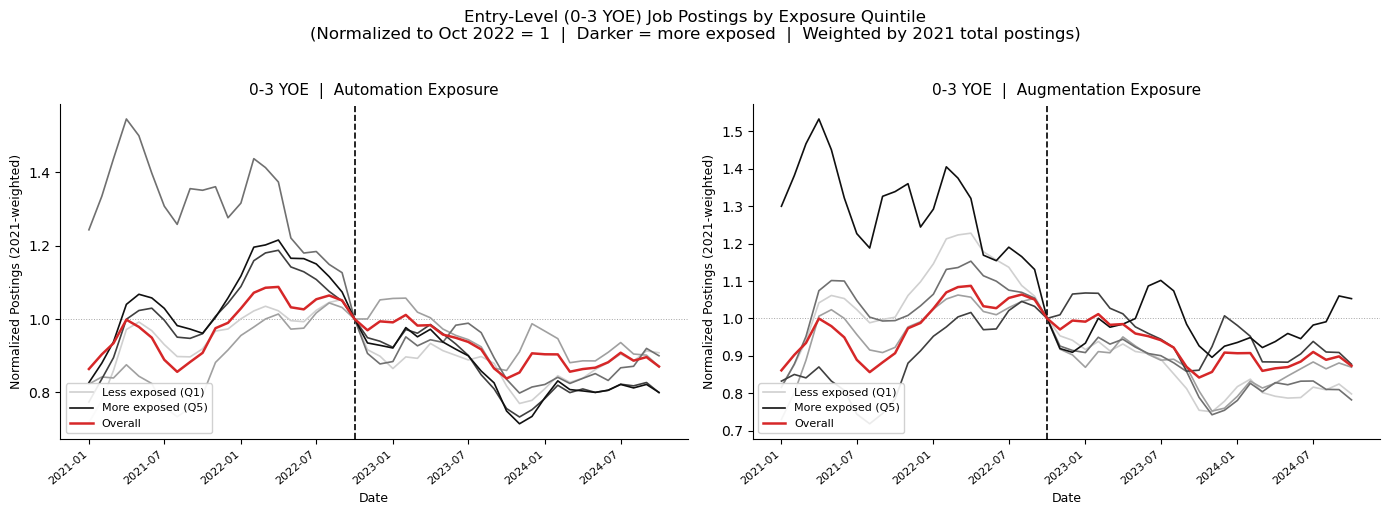

In [214]:
# ── Entry-level only: Automation vs Augmentation side by side ────────────
import matplotlib.pyplot as plt, matplotlib.dates as mdates, seaborn as sns
from matplotlib.lines import Line2D

weights_2021 = (df_all[df_all['year_month'].dt.year == 2021]
                .groupby('occ_code', as_index=False)['postings'].sum()
                .rename(columns={'postings': 'w_2021', 'occ_code': 'soc'}))
weights_2021['w_2021_pct'] = weights_2021['w_2021'] / weights_2021['w_2021'].sum()

base_date, cutoff_date = pd.Timestamp('2022-10-01'), pd.Timestamp('2024-10-01')
quintile_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
grays          = ['#d0d0d0', '#a0a0a0', '#707070', '#404040', '#101010']

measures = [
    ('automation_weighted_ratio',   'Automation Exposure'),
    ('augmentation_weighted_ratio', 'Augmentation Exposure'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (col, label) in zip(axes, measures):
    exp_q = ai_exposure_combined[['occ_code', col]].dropna().copy()
    exp_q = exp_q[exp_q[col] > 0]
    exp_q['quintile'] = pd.qcut(exp_q[col], 5, labels=['Q1','Q2','Q3','Q4','Q5'])

    df_merged = (df_yoe_occ[df_yoe_occ['yoe_bucket'] == '0-3 YOE']
                 .merge(exp_q[['occ_code','quintile']], left_on='soc', right_on='occ_code', how='inner')
                 .merge(weights_2021[['soc','w_2021_pct']], on='soc', how='left'))
    df_merged['wt_postings'] = df_merged['postings'] * df_merged['w_2021_pct']
    df_merged = df_merged[df_merged['year_month'] <= cutoff_date]

    # Overall line
    ov = df_merged.groupby('year_month', as_index=False)['wt_postings'].sum().sort_values('year_month')
    ov['smooth'] = ov['wt_postings'].rolling(3, center=True, min_periods=1).mean()
    bv = ov.loc[ov['year_month'] == base_date, 'smooth']
    if not bv.empty and bv.values[0] != 0:
        ov['norm'] = ov['smooth'] / bv.values[0]
        ax.plot(ov['year_month'], ov['norm'], color='#d62728', linewidth=1.8, zorder=5)

    # Quintile lines
    for q, color in zip(quintile_order, grays):
        g = (df_merged[df_merged['quintile'] == q]
             .groupby('year_month', as_index=False)['wt_postings'].sum()
             .sort_values('year_month'))
        if g.empty: continue
        g['smooth'] = g['wt_postings'].rolling(3, center=True, min_periods=1).mean()
        bv = g.loc[g['year_month'] == base_date, 'smooth']
        if bv.empty or bv.values[0] == 0: continue
        g['norm'] = g['smooth'] / bv.values[0]
        ax.plot(g['year_month'], g['norm'], color=color, linewidth=1.2, zorder=3)

    ax.axvline(base_date, color='black', linestyle='--', linewidth=1.2)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.set_title(f'0-3 YOE  |  {label}', fontsize=11)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Normalized Postings (2021-weighted)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=8)
    sns.despine(ax=ax)
    ax.legend(handles=[
        Line2D([0],[0], color=grays[0],  lw=1.2, label='Less exposed (Q1)'),
        Line2D([0],[0], color=grays[-1], lw=1.2, label='More exposed (Q5)'),
        Line2D([0],[0], color='#d62728', lw=1.8, label='Overall'),
    ], fontsize=8, framealpha=0.9, loc='lower left')

fig.suptitle('Entry-Level (0-3 YOE) Job Postings by Exposure Quintile\n'
             '(Normalized to Oct 2022 = 1  |  Darker = more exposed  |  Weighted by 2021 total postings)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/canaries_entry_auto_aug.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Regression

In [215]:
# ── DiD Regression — Step 1: Query entry-level share by occupation-month ──
# Y = entry_level_pct: what % of postings in an occupation-month are entry-level
# Entry-level = YOE ≤ 2  OR  (Junior seniority + NULL YOE)
# Universe: education ≤ Bachelor's, 2020-2024
import snowflake.connector as snow, os

conn = snow.connect(user=os.environ['SNOWFLAKE_USER'], password=os.environ['SNOWFLAKE_PASSWORD'],
                    account='avb99459.us-east-1', warehouse='OPPORTUNITYATWORK_WH')

df_did = pd.read_sql("""
SELECT date_trunc('month', p.posted)::date AS year_month,
       p.soc_2021_5                        AS occ_code,
       COUNT(DISTINCT p.id)                AS total_postings,
       COUNT(DISTINCT CASE
           WHEN p.min_years_experience <= 2
                OR (p.min_years_experience IS NULL AND p.job_seniority_name = 'Junior')
           THEN p.id END)                  AS entry_postings
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2020-01-01' AND '2025-03-01'
  AND p.soc_2021_5 IS NOT NULL
  AND p.min_edulevels_name IN ('No Education Listed', 'High school or GED', 'Associate degree', 'Bachelor''''s Degree')
GROUP BY 1, 2
ORDER BY 1, 2
""", conn)
conn.close()

df_did.columns = df_did.columns.str.lower()
df_did['year_month'] = pd.to_datetime(df_did['year_month'])
df_did['entry_level_pct'] = df_did['entry_postings'] / df_did['total_postings'] * 100

print(f'Rows: {len(df_did):,} | Occupations: {df_did["occ_code"].nunique()} | Months: {df_did["year_month"].nunique()}')
print(df_did.head())

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/677815552.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_did = pd.read_sql("""


Rows: 47,515 | Occupations: 767 | Months: 63
  year_month occ_code  total_postings  entry_postings  entry_level_pct
0 2020-01-01  11-1011            2239             680        30.370701
1 2020-01-01  11-1021           18676            7048        37.738274
2 2020-01-01  11-2011             262              76        29.007634
3 2020-01-01  11-2021            8311             967        11.635182
4 2020-01-01  11-2022           16302            2900        17.789228


In [216]:
# ── DiD — Step 2: Merge exposure + weights, create post, seasonal-adjust Y ─
# gpt4_beta: Eloundou et al. (2023) — task-level GPT-4 exposure, pre-ChatGPT
#   → preferred treatment: time-invariant, not endogenous to firm adoption
# w_2021:   occupation's 2021 posting share — bigger occupations get more weight
# post:     1 after Oct 2022 (ChatGPT launch), 0 before
# entry_sa: seasonally adjusted Y — OLS residuals on month dummies + grand mean
import statsmodels.formula.api as smf, numpy as np

gpt4 = pd.read_csv('/Users/khaliun/Documents/USF/ECON696/ai_exposure.csv')
gpt4['occ_code'] = gpt4['O*NET-SOC Code'].str[:7]
gpt4 = gpt4[['occ_code', 'gpt4_beta']].drop_duplicates('occ_code')
df_did = df_did.merge(gpt4, on='occ_code', how='left')

w2021 = (df_did[df_did['year_month'].dt.year == 2021]
         .groupby('occ_code', as_index=False)['total_postings'].sum()
         .rename(columns={'total_postings': 'tot_2021'}))
w2021['w_2021'] = w2021['tot_2021'] / w2021['tot_2021'].sum()
df_did = df_did.merge(w2021[['occ_code', 'w_2021']], on='occ_code', how='left')

df_did['post']   = (df_did['year_month'] >= pd.Timestamp('2022-10-01')).astype(int)
df_did['ym_str'] = df_did['year_month'].dt.strftime('%Y-%m')

df_reg = df_did.dropna(subset=['entry_level_pct', 'gpt4_beta', 'w_2021']).copy()
df_reg['month_str'] = df_reg['year_month'].dt.month.astype(str)
sa_model = smf.wls('entry_level_pct ~ C(month_str)', data=df_reg,
                   weights=df_reg['w_2021']).fit()
df_reg['entry_sa'] = sa_model.resid + df_reg['entry_level_pct'].mean()

print(f'N for regression: {len(df_reg):,} | Occupations: {df_reg["occ_code"].nunique()}')
print(f'entry_sa  — mean: {df_reg["entry_sa"].mean():.1f}%  std: {df_reg["entry_sa"].std():.1f}%')
print(f'gpt4_beta — mean: {df_reg["gpt4_beta"].mean():.2f}  range: [{df_reg["gpt4_beta"].min():.2f}, {df_reg["gpt4_beta"].max():.2f}]')

N for regression: 45,436 | Occupations: 733
entry_sa  — mean: 23.0%  std: 13.9%
gpt4_beta — mean: 0.32  range: [0.00, 1.00]


In [217]:
# ── DiD — Step 3: Construct rate_sensitivity_i (pre-period OLS per occ) ────
# rate_sensitivity: how much an occupation's hiring responds to ΔFFR
#   → measured in pre-period (Jan 2020 – Sep 2022) ONLY
#   → OLS: posting_pct_change ~ delta_FFR  per occupation
# Why this survives two-way FEs:
#   FFR level is the same for all occs each month → absorbed by γ_t
#   But sensitivity (the coefficient) varies across occupations → NOT absorbed
#   Construction, real estate = high sensitivity; software = low sensitivity

ffr_dict = {
    '2020-01': 1.54, '2020-02': 1.58, '2020-03': 0.65, '2020-04': 0.05,
    '2020-05': 0.05, '2020-06': 0.08, '2020-07': 0.09, '2020-08': 0.10,
    '2020-09': 0.09, '2020-10': 0.09, '2020-11': 0.09, '2020-12': 0.09,
    '2021-01': 0.07, '2021-02': 0.07, '2021-03': 0.07, '2021-04': 0.06,
    '2021-05': 0.06, '2021-06': 0.06, '2021-07': 0.07, '2021-08': 0.08,
    '2021-09': 0.08, '2021-10': 0.08, '2021-11': 0.08, '2021-12': 0.08,
    '2022-01': 0.08, '2022-02': 0.08, '2022-03': 0.20, '2022-04': 0.33,
    '2022-05': 0.77, '2022-06': 1.21, '2022-07': 1.68, '2022-08': 2.33,
    '2022-09': 3.08,
}
ffr = (pd.DataFrame(list(ffr_dict.items()), columns=['ym_str', 'ffr'])
       .assign(year_month=lambda d: pd.to_datetime(d['ym_str']))
       .assign(delta_ffr=lambda d: d['ffr'].diff()))

pre_cutoff = pd.Timestamp('2022-10-01')
df_pre = (df_reg[df_reg['year_month'] < pre_cutoff]
          .sort_values(['occ_code', 'year_month'])
          .merge(ffr[['year_month', 'delta_ffr']], on='year_month', how='left'))
df_pre['posting_pct_chg'] = (df_pre.groupby('occ_code')['total_postings']
                              .pct_change() * 100)

sensitivity = []
for occ, grp in df_pre.dropna(subset=['posting_pct_chg', 'delta_ffr']).groupby('occ_code'):
    if len(grp) < 12: continue
    m = smf.ols('posting_pct_chg ~ delta_ffr', data=grp).fit()
    sensitivity.append({'occ_code': occ, 'rate_sensitivity': m.params['delta_ffr']})
df_sens = pd.DataFrame(sensitivity)

p01, p99 = df_sens['rate_sensitivity'].quantile([0.01, 0.99])
df_sens['rate_sensitivity'] = df_sens['rate_sensitivity'].clip(p01, p99)
print(f'Rate sensitivity computed for {len(df_sens)} occupations')
print(df_sens['rate_sensitivity'].describe().round(2))

Rate sensitivity computed for 729 occupations
count    729.00
mean       2.63
std       17.48
min      -97.59
25%       -2.44
50%        4.40
75%       10.54
max       47.23
Name: rate_sensitivity, dtype: float64


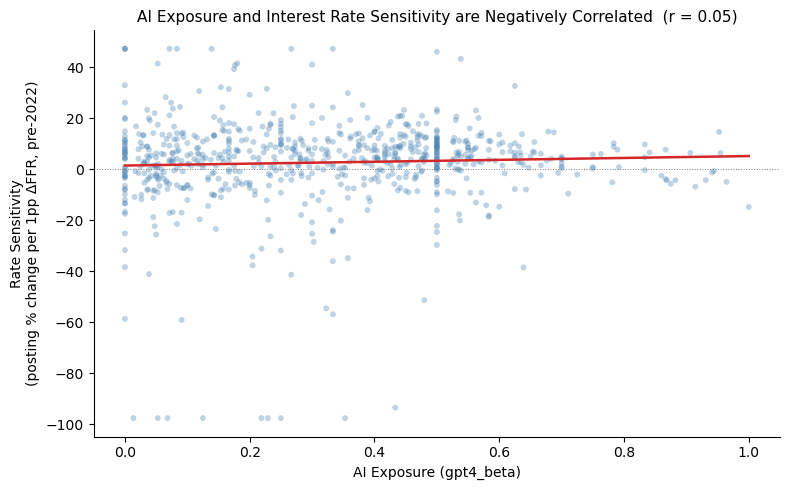

r = 0.047  →  AI-exposed occupations are less rate-sensitive
Omitting this control biases β toward zero (attenuates AI estimate)


In [218]:
# ── DiD — Step 4: AI exposure vs rate sensitivity scatter ───────────────────
# Replicates Brynjolfsson et al. Figure A22
# Key insight: AI-exposed occupations are LESS rate-sensitive
#   → Omitting rate sensitivity ATTENUATES β (biases toward zero)
#   → Controlling for it should INCREASE the AI coefficient
import matplotlib.pyplot as plt, seaborn as sns

scatter_df = df_reg.drop_duplicates('occ_code').merge(df_sens, on='occ_code', how='inner')
corr = scatter_df[['gpt4_beta', 'rate_sensitivity']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(scatter_df['gpt4_beta'], scatter_df['rate_sensitivity'],
           alpha=0.35, s=18, color='steelblue', edgecolors='none')
xs = np.linspace(scatter_df['gpt4_beta'].min(), scatter_df['gpt4_beta'].max(), 100)
m_scatter = smf.ols('rate_sensitivity ~ gpt4_beta', data=scatter_df).fit()
ax.plot(xs, m_scatter.predict(pd.DataFrame({'gpt4_beta': xs})),
        color='#d62728', linewidth=1.8)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.7)
ax.set_xlabel('AI Exposure (gpt4_beta)', fontsize=10)
ax.set_ylabel('Rate Sensitivity\n(posting % change per 1pp ΔFFR, pre-2022)', fontsize=10)
ax.set_title(f'AI Exposure and Interest Rate Sensitivity are Negatively Correlated  (r = {corr:.2f})',
             fontsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/Users/khaliun/Documents/USF/ECON696/writeup/figures/ai_vs_rate_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'r = {corr:.3f}  →  AI-exposed occupations are less rate-sensitive')
print('Omitting this control biases β toward zero (attenuates AI estimate)')

In [219]:
# ── DiD — Step 5: Main regression (two-way FE, WLS, clustered SEs) ─────────
#
#  EntryShare_it = β·(Post_t × GPT4Exp_i) + α_i + γ_t + ε_it
#
#  Y       = entry_sa       seasonally adjusted entry-level share (%)
#  β       = post:gpt4_beta  ← the DiD estimator: differential post-ChatGPT
#                              change per unit of AI exposure
#  α_i     = C(occ_code)    occupation FE — absorbs permanent cross-occ differences
#  γ_t     = C(ym_str)      time FE — absorbs all common macro shocks each month
#  Weights = w_2021          2021 posting share (larger occs get more weight)
#  SEs     = clustered by occupation (serial correlation within occ over time)

model_main = smf.wls(
    'entry_sa ~ post:gpt4_beta + C(occ_code) + C(ym_str)',
    data=df_reg, weights=df_reg['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['occ_code']})

c1_, se1_, p1_ = (model_main.params['post:gpt4_beta'],
                  model_main.bse['post:gpt4_beta'],
                  model_main.pvalues['post:gpt4_beta'])
ci1_ = model_main.conf_int().loc['post:gpt4_beta']

print('Spec 1 — Main (YOE≤2 + Junior+NULL, edu≤Bachelor\'s)')
print(f'  β = {c1_:.3f}  SE = {se1_:.3f}  p = {p1_:.3f}  95% CI = [{ci1_[0]:.3f}, {ci1_[1]:.3f}]')
print(f'  N obs: {int(model_main.nobs):,} | N occupations: {df_reg["occ_code"].nunique()}')
print()
print('Benchmark: Software Dev (gpt4=0.94) vs Truck Driver (gpt4=0.04)')
print(f'  → {(0.94-0.04)*c1_:+.3f} pp differential decline in entry-level share post-ChatGPT')

Spec 1 — Main (YOE≤2 + Junior+NULL, edu≤Bachelor's)
  β = -1.729  SE = 0.898  p = 0.054  95% CI = [-3.490, 0.032]
  N obs: 45,436 | N occupations: 733

Benchmark: Software Dev (gpt4=0.94) vs Truck Driver (gpt4=0.04)
  → -1.556 pp differential decline in entry-level share post-ChatGPT


In [220]:
# ── DiD — Step 6: + demand shock control  (post × avg_demand_change_post_i) ─
# avg_demand_change_post: occupation's avg 12m posting % change in the post-period
# Why we need it:
#   Tech postings fell ~40% after 2022 (layoffs) — this hits high-AI occupations
#   γ_t absorbs common monthly shocks, NOT occupation-specific divergence
#   If we don't control for this, β might capture 'tech collapsed' not 'AI cut entry'
# Correlation with gpt4_beta: r ≈ -0.18 → mostly separate variation

demand = (df_reg.sort_values(['occ_code', 'year_month'])
          .assign(pct_chg=lambda d: d.groupby('occ_code')['total_postings'].pct_change(12) * 100)
          .query('post == 1')
          .groupby('occ_code')['pct_chg'].mean()
          .reset_index()
          .rename(columns={'pct_chg': 'avg_demand_change_post'}))

df_ds = df_reg.merge(demand, on='occ_code', how='left').dropna(
    subset=['entry_sa', 'gpt4_beta', 'w_2021', 'avg_demand_change_post'])

model_ds = smf.wls(
    'entry_sa ~ post:gpt4_beta + post:avg_demand_change_post + C(occ_code) + C(ym_str)',
    data=df_ds, weights=df_ds['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_ds['occ_code']})

c2_, se2_, p2_ = (model_ds.params['post:gpt4_beta'],
                  model_ds.bse['post:gpt4_beta'],
                  model_ds.pvalues['post:gpt4_beta'])
ci2_ = model_ds.conf_int().loc['post:gpt4_beta']
corr_d = demand.merge(df_reg.drop_duplicates('occ_code')[['occ_code','gpt4_beta']],
                      on='occ_code')[['avg_demand_change_post','gpt4_beta']].corr().iloc[0,1]
print('Spec 2 — + demand shock control')
print(f'  β = {c2_:.3f}  SE = {se2_:.3f}  p = {p2_:.3f}  95% CI = [{ci2_[0]:.3f}, {ci2_[1]:.3f}]')
print(f'  Corr(demand_change, gpt4_beta) = {corr_d:.3f}  (near-zero → separate variation)')

Spec 2 — + demand shock control
  β = -1.732  SE = 0.909  p = 0.057  95% CI = [-3.514, 0.049]
  Corr(demand_change, gpt4_beta) = -0.148  (near-zero → separate variation)


In [221]:
# ── DiD — Step 7: + rate sensitivity control  (post × rate_sensitivity_i) ───
# Why adding this INCREASES β (the key robustness result):
#   AI-exposed occs are LESS rate-sensitive (r < 0, see scatter above)
#   Rate hike 2022-23 hurt low-AI, high-rate-sensitive sectors (construction)
#   Without control: those sectors show RISING entry share → attenuates our β
#   With control: the AI effect is isolated from the rate-cycle effect
#   → β gets larger, p improves: this rules out 'it's the rate hike, not AI'

df_rate = df_ds.merge(df_sens, on='occ_code', how='inner').dropna(
    subset=['entry_sa', 'gpt4_beta', 'w_2021', 'avg_demand_change_post', 'rate_sensitivity'])

model_rate = smf.wls(
    'entry_sa ~ post:gpt4_beta + post:avg_demand_change_post + post:rate_sensitivity'
    ' + C(occ_code) + C(ym_str)',
    data=df_rate, weights=df_rate['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_rate['occ_code']})

c3_, se3_, p3_ = (model_rate.params['post:gpt4_beta'],
                  model_rate.bse['post:gpt4_beta'],
                  model_rate.pvalues['post:gpt4_beta'])
ci3_ = model_rate.conf_int().loc['post:gpt4_beta']
print('Spec 3 — + demand shock + rate sensitivity')
print(f'  β = {c3_:.3f}  SE = {se3_:.3f}  p = {p3_:.3f}  95% CI = [{ci3_[0]:.3f}, {ci3_[1]:.3f}]')
print()
print('Key result: β becomes MORE negative after adding rate control')
print('→ interest rates were attenuating, not inflating, the AI estimate')

Spec 3 — + demand shock + rate sensitivity
  β = -1.979  SE = 0.844  p = 0.019  95% CI = [-3.632, -0.326]

Key result: β becomes MORE negative after adding rate control
→ interest rates were attenuating, not inflating, the AI estimate


In [222]:
# ── DiD — Step 7b: + rate sensitivity ONLY  (no demand shock control) ───────
# Isolates the rate-cycle effect independently before combining controls
# Shows β moves even when demand shock is not included

df_rate_only = df_reg.merge(df_sens, on='occ_code', how='inner').dropna(
    subset=['entry_sa', 'gpt4_beta', 'w_2021', 'rate_sensitivity'])

model_rate_only = smf.wls(
    'entry_sa ~ post:gpt4_beta + post:rate_sensitivity + C(occ_code) + C(ym_str)',
    data=df_rate_only, weights=df_rate_only['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_rate_only['occ_code']})

c_ro, se_ro, p_ro = (model_rate_only.params['post:gpt4_beta'],
                     model_rate_only.bse['post:gpt4_beta'],
                     model_rate_only.pvalues['post:gpt4_beta'])
ci_ro = model_rate_only.conf_int().loc['post:gpt4_beta']
print('Spec 3 — + rate sensitivity ONLY')
print(f'  β = {c_ro:.3f}  SE = {se_ro:.3f}  p = {p_ro:.3f}  95% CI = [{ci_ro[0]:.3f}, {ci_ro[1]:.3f}]')

Spec 3 — + rate sensitivity ONLY
  β = -1.926  SE = 0.824  p = 0.019  95% CI = [-3.540, -0.312]


In [223]:
# ── DiD — Summary table (2 specifications) ───────────────────────────────────
results = pd.DataFrame([
    {"Specification": "(1) Main DiD",
     "β": round(c1_, 3), "SE": round(se1_, 3), "p": round(p1_, 3),
     "95% CI": f"[{ci1_[0]:.3f}, {ci1_[1]:.3f}]"},
    {"Specification": "(2) + rate sensitivity control",
     "β": round(c_ro, 3), "SE": round(se_ro, 3), "p": round(p_ro, 3),
     "95% CI": f"[{ci_ro[0]:.3f}, {ci_ro[1]:.3f}]"},
])

print("DiD Results — Effect of AI Exposure on Entry-Level Posting Share")
print("Y = entry_sa (seasonally adjusted, %)  |  Treatment = gpt4_beta (0-1 scale)")
print("All: occupation + time FEs, WLS (2021 weights), SEs clustered by occupation")
print()
print(results.to_string(index=False))
print()
print(f"Benchmark: Software Dev (0.94) vs Truck Driver (0.04) → 0.90 unit gap in treatment")
print(f"  Key spec implied gap: 0.90 × {c_ro:.3f} = {0.90*c_ro:.3f} pp differential decline")
print()
print("Note: demand shock control excluded — β unchanged (−1.729 → −1.732), adds no explanatory value")

DiD Results — Effect of AI Exposure on Entry-Level Posting Share
Y = entry_sa (seasonally adjusted, %)  |  Treatment = gpt4_beta (0-1 scale)
All: occupation + time FEs, WLS (2021 weights), SEs clustered by occupation

                 Specification      β    SE     p           95% CI
                  (1) Main DiD -1.729 0.898 0.054  [-3.490, 0.032]
(2) + rate sensitivity control -1.926 0.824 0.019 [-3.540, -0.312]

Benchmark: Software Dev (0.94) vs Truck Driver (0.04) → 0.90 unit gap in treatment
  Key spec implied gap: 0.90 × -1.926 = -1.733 pp differential decline

Note: demand shock control excluded — β unchanged (−1.729 → −1.732), adds no explanatory value


In [224]:
# ── Robustness: DiD with observed_exposure (Anthropic Economic Index) ────────
# observed_exposure = actual Claude usage at occupation level (post-ChatGPT)
# Caveat: partially endogenous — measured after ChatGPT launch, so firms that
#   already cut entry-level hiring may have adopted AI more → use as directional check only
# If both gpt4_beta and observed_exposure give negative β, the story is consistent

anthro = pd.read_csv('/Users/khaliun/Documents/USF/ECON696/ai_exposure_combined.csv')
anthro = anthro[['occ_code', 'observed_exposure']].dropna().drop_duplicates('occ_code')

df_obs = df_reg.merge(anthro, on='occ_code', how='inner').dropna(
    subset=['entry_sa', 'observed_exposure', 'w_2021'])

print(f'N for observed_exposure regression: {len(df_obs):,} | Occupations: {df_obs["occ_code"].nunique()}')
print(f'observed_exposure — mean: {df_obs["observed_exposure"].mean():.3f}  range: [{df_obs["observed_exposure"].min():.3f}, {df_obs["observed_exposure"].max():.3f}]')

model_obs_main = smf.wls(
    'entry_sa ~ post:observed_exposure + C(occ_code) + C(ym_str)',
    data=df_obs, weights=df_obs['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_obs['occ_code']})

c_o1, se_o1, p_o1 = (model_obs_main.params['post:observed_exposure'],
                     model_obs_main.bse['post:observed_exposure'],
                     model_obs_main.pvalues['post:observed_exposure'])
ci_o1 = model_obs_main.conf_int().loc['post:observed_exposure']
print()
print('Spec 1 — observed_exposure, Main DiD')
print(f'  β = {c_o1:.3f}  SE = {se_o1:.3f}  p = {p_o1:.3f}  95% CI = [{ci_o1[0]:.3f}, {ci_o1[1]:.3f}]')

N for observed_exposure regression: 44,403 | Occupations: 716
observed_exposure — mean: 0.074  range: [0.000, 0.745]

Spec 1 — observed_exposure, Main DiD
  β = -2.243  SE = 0.921  p = 0.015  95% CI = [-4.047, -0.439]


In [225]:
# ── Robustness: observed_exposure DiD + rate sensitivity control ─────────────

df_obs_rate = df_obs.merge(df_sens, on='occ_code', how='inner').dropna(
    subset=['entry_sa', 'observed_exposure', 'w_2021', 'rate_sensitivity'])

model_obs_rate = smf.wls(
    'entry_sa ~ post:observed_exposure + post:rate_sensitivity + C(occ_code) + C(ym_str)',
    data=df_obs_rate, weights=df_obs_rate['w_2021']
).fit(cov_type='cluster', cov_kwds={'groups': df_obs_rate['occ_code']})

c_o2, se_o2, p_o2 = (model_obs_rate.params['post:observed_exposure'],
                     model_obs_rate.bse['post:observed_exposure'],
                     model_obs_rate.pvalues['post:observed_exposure'])
ci_o2 = model_obs_rate.conf_int().loc['post:observed_exposure']
print('Spec 2 — observed_exposure + rate sensitivity')
print(f'  β = {c_o2:.3f}  SE = {se_o2:.3f}  p = {p_o2:.3f}  95% CI = [{ci_o2[0]:.3f}, {ci_o2[1]:.3f}]')

Spec 2 — observed_exposure + rate sensitivity
  β = -2.426  SE = 0.889  p = 0.006  95% CI = [-4.169, -0.684]


#Regression results:

In [226]:
# ── Robustness summary: observed_exposure vs gpt4_beta ──────────────────────
rob = pd.DataFrame([
    {'Treatment': 'gpt4_beta (Eloundou et al.)',
     'Specification': '(1) Main DiD',
     'β': round(c1_, 3), 'SE': round(se1_, 3), 'p': round(p1_, 3),
     '95% CI': f'[{ci1_[0]:.3f}, {ci1_[1]:.3f}]'},
    {'Treatment': 'gpt4_beta (Eloundou et al.)',
     'Specification': '(2) + rate sensitivity',
     'β': round(c_ro, 3), 'SE': round(se_ro, 3), 'p': round(p_ro, 3),
     '95% CI': f'[{ci_ro[0]:.3f}, {ci_ro[1]:.3f}]'},
    {'Treatment': 'observed_exposure (Anthropic)',
     'Specification': '(1) Main DiD',
     'β': round(c_o1, 3), 'SE': round(se_o1, 3), 'p': round(p_o1, 3),
     '95% CI': f'[{ci_o1[0]:.3f}, {ci_o1[1]:.3f}]'},
    {'Treatment': 'observed_exposure (Anthropic)',
     'Specification': '(2) + rate sensitivity',
     'β': round(c_o2, 3), 'SE': round(se_o2, 3), 'p': round(p_o2, 3),
     '95% CI': f'[{ci_o2[0]:.3f}, {ci_o2[1]:.3f}]'},
])

print('Robustness — Two AI Exposure Measures')
print('Y = entry_sa  |  occupation + time FEs  |  WLS  |  SEs clustered by occupation')
print('gpt4_beta: ChatGPT task exposure   |  observed_exposure: claude usage')
print()
print(rob.to_string(index=False))
print()
if c_o1 < 0 and c_o2 < 0:
    print('✓ Both measures negative — directionally consistent')
else:
    print('! Signs differ — check overlap between measures')

Robustness — Two AI Exposure Measures
Y = entry_sa  |  occupation + time FEs  |  WLS  |  SEs clustered by occupation
gpt4_beta: ChatGPT task exposure   |  observed_exposure: claude usage

                    Treatment          Specification      β    SE     p           95% CI
  gpt4_beta (Eloundou et al.)           (1) Main DiD -1.729 0.898 0.054  [-3.490, 0.032]
  gpt4_beta (Eloundou et al.) (2) + rate sensitivity -1.926 0.824 0.019 [-3.540, -0.312]
observed_exposure (Anthropic)           (1) Main DiD -2.243 0.921 0.015 [-4.047, -0.439]
observed_exposure (Anthropic) (2) + rate sensitivity -2.426 0.889 0.006 [-4.169, -0.684]

✓ Both measures negative — directionally consistent


In [227]:
# ── NULL YOE Check: what % of postings have no YOE specified? ───────────────
# Key question: did high-AI firms increasingly drop YOE requirements post-ChatGPT?
import snowflake.connector as snow, os

conn = snow.connect(user=os.environ["SNOWFLAKE_USER"], password=os.environ["SNOWFLAKE_PASSWORD"],
                    account="avb99459.us-east-1", warehouse="OPPORTUNITYATWORK_WH")

df_null = pd.read_sql("""
SELECT 'Overall' AS grp,
       CASE WHEN p.posted < '2022-10-01' THEN 'Pre-ChatGPT (2021-Sep 2022)'
            ELSE 'Post-ChatGPT (Oct 2022-2024)' END AS period,
       COUNT(DISTINCT p.id) AS total_postings,
       COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END) AS null_yoe,
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END)
             / NULLIF(COUNT(DISTINCT p.id),0), 1) AS pct_null_yoe
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2024-10-01'
  AND p.min_edulevels_name IN ('No Education Listed', 'High school or GED', 'Associate degree', 'Bachelor''''s Degree')
GROUP BY 2

UNION ALL

SELECT 'Software Developers (15-1252)' AS grp,
       CASE WHEN p.posted < '2022-10-01' THEN 'Pre-ChatGPT (2021-Sep 2022)'
            ELSE 'Post-ChatGPT (Oct 2022-2024)' END AS period,
       COUNT(DISTINCT p.id),
       COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END)
             / NULLIF(COUNT(DISTINCT p.id),0), 1)
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2024-10-01'
  AND p.soc_2021_5 = '15-1252'
  AND p.min_edulevels_name IN ('No Education Listed', 'High school or GED', 'Associate degree', 'Bachelor''''s Degree')
GROUP BY 2

UNION ALL

SELECT 'Finance & Accounting (13-2XXX)' AS grp,
       CASE WHEN p.posted < '2022-10-01' THEN 'Pre-ChatGPT (2021-Sep 2022)'
            ELSE 'Post-ChatGPT (Oct 2022-2024)' END AS period,
       COUNT(DISTINCT p.id),
       COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END),
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN p.min_years_experience IS NULL THEN p.id END)
             / NULLIF(COUNT(DISTINCT p.id),0), 1)
FROM emsi.us.postings p
WHERE p.posted BETWEEN '2021-01-01' AND '2024-10-01'
  AND LEFT(p.soc_2021_5, 4) = '13-2'
  AND p.min_edulevels_name IN ('No Education Listed', 'High school or GED', 'Associate degree', 'Bachelor''''s Degree')
GROUP BY 2

ORDER BY grp, period
""", conn)
conn.close()

df_null.columns = df_null.columns.str.lower()
print(df_null.to_string(index=False))
print()
print("Key: if pct_null_yoe INCREASES post-ChatGPT in SWE/Finance → firms dropping YOE requirements")
print("     if STABLE → selection concern is limited, charts are representative")

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/162964339.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null = pd.read_sql("""


                           grp                       period  total_postings  null_yoe  pct_null_yoe
Finance & Accounting (13-2XXX) Post-ChatGPT (Oct 2022-2024)          718391    350414          48.8
Finance & Accounting (13-2XXX)  Pre-ChatGPT (2021-Sep 2022)          764336    376567          49.3
                       Overall Post-ChatGPT (Oct 2022-2024)        62280963  37720502          60.6
                       Overall  Pre-ChatGPT (2021-Sep 2022)        62323330  38921556          62.5
 Software Developers (15-1252) Post-ChatGPT (Oct 2022-2024)          649822    298459          45.9
 Software Developers (15-1252)  Pre-ChatGPT (2021-Sep 2022)          935567    447450          47.8

Key: if pct_null_yoe INCREASES post-ChatGPT in SWE/Finance → firms dropping YOE requirements
     if STABLE → selection concern is limited, charts are representative


In [ ]:
#Robust across alternative samples (without tech sector, non-teleworkable, etc.) 

## Event Study

Querying strict YOE < 2 ...


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_14240/3033719685.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_strict_raw = pd.read_sql("""


Strict raw: 45,548 obs | 733 occs
main_gpt4      :  678 occs | 45 months
main_obs       :  678 occs | 45 months
strict_gpt4    :  681 occs | 45 months
strict_obs     :  681 occs | 45 months

Running 4 event studies ...
Done.


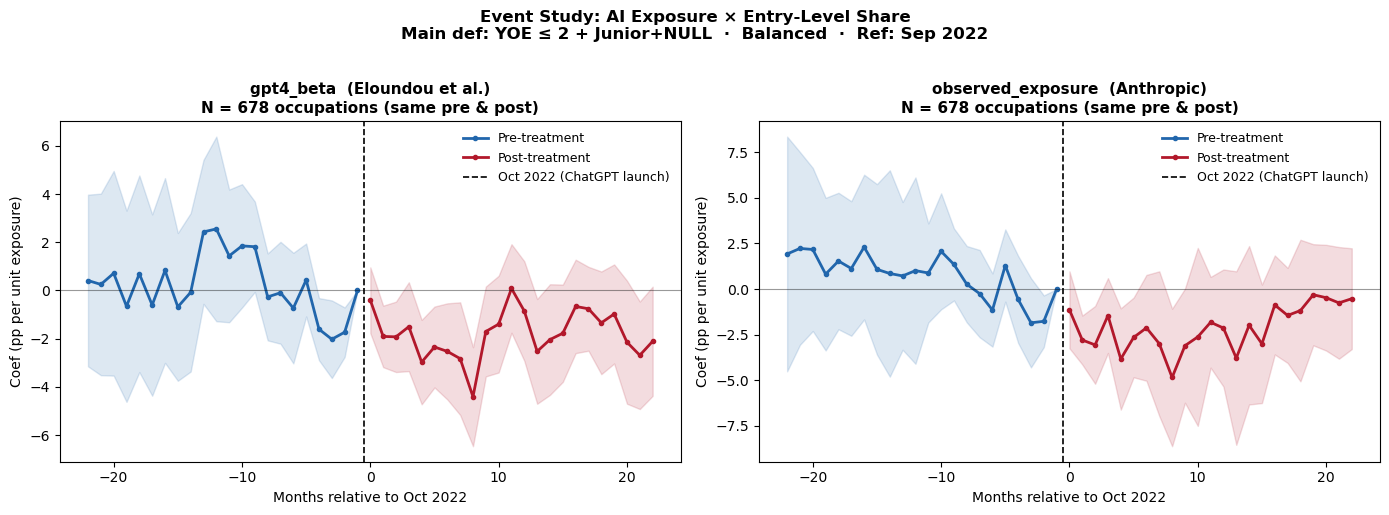

Saved → /Users/khaliun/Documents/USF/ECON696/slide_figures/event_study_main.png


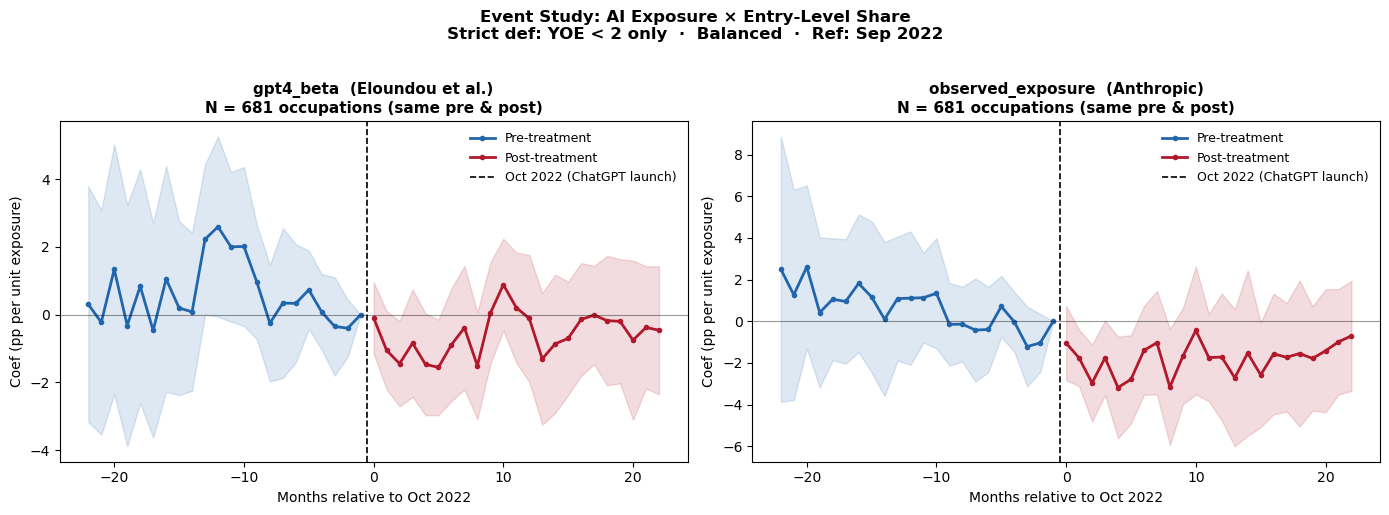

Saved → /Users/khaliun/Documents/USF/ECON696/slide_figures/event_study_strict.png


In [240]:
# ── Event Study (matched style): 2 panels side by side ───────────────────────
#
# Style: pre=blue, post=red, markers, axvline at −0.5
# Balanced panel: same occupations in EVERY month AND same occupations across
#   both panels within each figure (gpt4_beta ∩ observed_exposure intersection)
# Two figures: (1) Main def YOE ≤ 2 + Junior+NULL
#              (2) Strict def YOE < 2 only
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import snowflake.connector as snow, os

WINDOW      = (-22, 22)
SAVE_MAIN   = '/Users/khaliun/Documents/USF/ECON696/slide_figures/event_study_main.png'
SAVE_STRICT = '/Users/khaliun/Documents/USF/ECON696/slide_figures/event_study_strict.png'

# ── 0. Ensure event_time on df_reg / df_obs ──────────────────────────────────
for d in [df_reg, df_obs]:
    if 'event_time' not in d.columns:
        d['event_time'] = (
            (d['year_month'].dt.year  - 2022) * 12 +
            (d['year_month'].dt.month - 10)
        )

# ── 1. Snowflake: strict YOE < 2 ─────────────────────────────────────────────
print('Querying strict YOE < 2 ...')
conn = snow.connect(user=os.environ['SNOWFLAKE_USER'],
                    password=os.environ['SNOWFLAKE_PASSWORD'],
                    account='avb99459.us-east-1', warehouse='OPPORTUNITYATWORK_WH')
df_strict_raw = pd.read_sql("""
    SELECT date_trunc('month', p.posted)::date AS year_month,
           p.soc_2021_5                         AS occ_code,
           COUNT(DISTINCT p.id)                 AS total_postings,
           COUNT(DISTINCT CASE
               WHEN p.min_years_experience < 2
               THEN p.id END)                   AS entry_postings
    FROM emsi.us.postings p
    WHERE p.posted BETWEEN '2020-01-01' AND '2025-03-01'
      AND p.soc_2021_5 IS NOT NULL
      AND (p.min_edulevels_name IN ('No Education Listed',
                                    'High school or GED',
                                    'Associate degree')
           OR LOWER(p.min_edulevels_name) LIKE '%bachelor%')
    GROUP BY 1, 2 ORDER BY 1, 2
""", conn)
conn.close()

df_strict_raw.columns      = df_strict_raw.columns.str.lower()
df_strict_raw['year_month'] = pd.to_datetime(df_strict_raw['year_month'])
df_strict_raw['entry_level_pct'] = (df_strict_raw['entry_postings']
                                      / df_strict_raw['total_postings'] * 100)

gpt4   = pd.read_csv('/Users/khaliun/Documents/USF/ECON696/ai_exposure.csv')
gpt4['occ_code'] = gpt4['O*NET-SOC Code'].str[:7]
gpt4   = gpt4[['occ_code','gpt4_beta']].drop_duplicates('occ_code')
anthro = pd.read_csv('/Users/khaliun/Documents/USF/ECON696/ai_exposure_combined.csv')
anthro = anthro[['occ_code','observed_exposure']].dropna().drop_duplicates('occ_code')

df_strict_raw = (df_strict_raw
    .merge(gpt4,  on='occ_code', how='left')
    .merge(anthro, on='occ_code', how='left')
    .merge(w2021[['occ_code','w_2021']], on='occ_code', how='left')
)
df_strict_raw['event_time'] = (
    (df_strict_raw['year_month'].dt.year  - 2022) * 12 +
    (df_strict_raw['year_month'].dt.month - 10)
)
df_strict_raw['ym_str'] = df_strict_raw['year_month'].dt.strftime('%Y-%m')

df_strict = df_strict_raw.dropna(subset=['entry_level_pct','gpt4_beta','w_2021']).copy()
df_strict['month_str'] = df_strict['year_month'].dt.month.astype(str)
sa_s = smf.wls('entry_level_pct ~ C(month_str)', data=df_strict,
               weights=df_strict['w_2021']).fit()
df_strict['entry_sa'] = sa_s.resid + df_strict['entry_level_pct'].mean()
print(f'Strict raw: {len(df_strict):,} obs | {df_strict["occ_code"].nunique()} occs')

# ── 2. Balance each dataset over window ──────────────────────────────────────
def balance(df, window=WINDOW):
    lo, hi   = window
    df       = df[(df['event_time'] >= lo) & (df['event_time'] <= hi)].copy()
    n_months = hi - lo + 1
    counts   = df.groupby('occ_code')['event_time'].nunique()
    keep     = counts[counts == n_months].index
    return df[df['occ_code'].isin(keep)].copy()

b_main_gpt4   = balance(df_reg.dropna(subset=['entry_sa','gpt4_beta','w_2021']))
b_main_obs    = balance(df_obs.dropna(subset=['entry_sa','observed_exposure','w_2021']))
b_strict_gpt4 = balance(df_strict.dropna(subset=['entry_sa','gpt4_beta','w_2021']))
b_strict_obs  = balance(df_strict.dropna(subset=['entry_sa','observed_exposure','w_2021']))

# ── 3. Intersect occupations within each figure ───────────────────────────────
# Both panels in a figure must show the SAME occupations (gpt4 ∩ observed)
def intersect(d1, d2):
    common = set(d1['occ_code'].unique()) & set(d2['occ_code'].unique())
    return d1[d1['occ_code'].isin(common)].copy(), d2[d2['occ_code'].isin(common)].copy()

f_main_gpt4,   f_main_obs   = intersect(b_main_gpt4,   b_main_obs)
f_strict_gpt4, f_strict_obs = intersect(b_strict_gpt4, b_strict_obs)

for name, df in [('main_gpt4',   f_main_gpt4),   ('main_obs',    f_main_obs),
                  ('strict_gpt4', f_strict_gpt4), ('strict_obs',  f_strict_obs)]:
    print(f'{name:15s}: {df["occ_code"].nunique():4d} occs | {df["event_time"].nunique()} months')

# ── 4. Event study regression ─────────────────────────────────────────────────
def run_es(df, treatment, ref=-1):
    event_times = sorted(df['event_time'].unique())
    non_ref = [t for t in event_times if t != ref]
    col_map = {t: f'_et{t+100}' for t in non_ref}
    df = df.copy()
    for t, col in col_map.items():
        df[col] = (df['event_time'] == t).astype(float) * df[treatment]
    formula = f'entry_sa ~ {" + ".join(col_map.values())} + C(occ_code) + C(ym_str)'
    m = smf.wls(formula, data=df, weights=df['w_2021']).fit(
        cov_type='cluster', cov_kwds={'groups': df['occ_code']}
    )
    rows = [
        {'event_time': t, 'coef': m.params[col],
         'ci_lo': m.conf_int().loc[col, 0],
         'ci_hi': m.conf_int().loc[col, 1]}
        for t, col in col_map.items() if col in m.params
    ]
    rows.append({'event_time': ref, 'coef': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0})
    return pd.DataFrame(rows).sort_values('event_time').reset_index(drop=True)

print('\nRunning 4 event studies ...')
es_main_gpt4   = run_es(f_main_gpt4,   'gpt4_beta')
es_main_obs    = run_es(f_main_obs,    'observed_exposure')
es_strict_gpt4 = run_es(f_strict_gpt4, 'gpt4_beta')
es_strict_obs  = run_es(f_strict_obs,  'observed_exposure')
print('Done.')

# ── 5. Plot ───────────────────────────────────────────────────────────────────
BLUE, RED = '#2166ac', '#b2182b'

def plot_es(ax, data, title, n_occ):
    pre  = data[data['event_time'] <= -1].sort_values('event_time')
    post = data[data['event_time'] >=  0].sort_values('event_time')
    ax.plot(pre['event_time'],  pre['coef'],  color=BLUE, lw=2, marker='o', ms=3,
            label='Pre-treatment')
    ax.fill_between(pre['event_time'],  pre['ci_lo'],  pre['ci_hi'],
                    alpha=0.15, color=BLUE)
    ax.plot(post['event_time'], post['coef'], color=RED,  lw=2, marker='o', ms=3,
            label='Post-treatment')
    ax.fill_between(post['event_time'], post['ci_lo'], post['ci_hi'],
                    alpha=0.15, color=RED)
    ax.axvline(-0.5, color='black', lw=1.2, ls='--', label='Oct 2022 (ChatGPT launch)')
    ax.axhline(0,    color='black', lw=0.8, alpha=0.4)
    ax.set_xlabel('Months relative to Oct 2022', fontsize=10)
    ax.set_ylabel('Coef (pp per unit exposure)', fontsize=10)
    ax.set_title(f'{title}\nN = {n_occ:,} occupations (same pre & post)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, frameon=False)

def make_fig(es_gpt4, es_obs, n_occ, suptitle, savepath):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_es(axes[0], es_gpt4, 'gpt4_beta  (Eloundou et al.)',   n_occ)
    plot_es(axes[1], es_obs,  'observed_exposure  (Anthropic)',  n_occ)
    plt.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {savepath}')

n_main   = f_main_gpt4['occ_code'].nunique()
n_strict = f_strict_gpt4['occ_code'].nunique()

make_fig(es_main_gpt4, es_main_obs, n_main,
    'Event Study: AI Exposure × Entry-Level Share\n'
    'Main def: YOE ≤ 2 + Junior+NULL  ·  Balanced  ·  Ref: Sep 2022',
    SAVE_MAIN)

make_fig(es_strict_gpt4, es_strict_obs, n_strict,
    'Event Study: AI Exposure × Entry-Level Share\n'
    'Strict def: YOE < 2 only  ·  Balanced  ·  Ref: Sep 2022',
    SAVE_STRICT)
